In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from lightgbm import LGBMRegressor, LGBMClassifier
import sys
import re
from sklearn.preprocessing import LabelEncoder

In [73]:
df_listings = pd.read_csv("../data/Listing/listed_transactions.csv")
df_listings.head()

C:\Users\mayab\AppData\Local\Temp\ipykernel_36632\3410094314.py:1: DtypeWarning: Columns (0: ListAgentEmail, 1: BuyerAgencyCompensationType) have mixed types. Specify dtype option on import or set low_memory=False.
  df_listings = pd.read_csv("../data/Listing/listed_transactions.csv")


,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,Latitude,Longitude,UnparsedAddress,...,HighSchoolDistrict,PostalCode,BuyerOfficeName.1,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,UnparsedAddress.1,Year,year_month,rate_30yr_fixed
0,90000.0,1075010398,miriamlara03@gmail.com,NaN,NaN,Miriam,Lara,34.097939,-117.909653,1045 N Azusa 61,...,Covina Valley Unified,91722,NaN,0.0,NaN,NaN,1045 N Azusa 61,2024,2024-01,6.6425
1,1500000.0,1074974457,janelle@judsonre.com,NaN,NaN,Janelle,Judson,33.121241,-117.081614,NaN,...,NaN,92025,NaN,0.0,NaN,NaN,NaN,2024,2024-01,6.6425
2,1340000.0,1074973329,haleh360@Gmail.com,NaN,NaN,Haleh,Dowlatshahi,34.052207,-118.408445,2220 Avenue Of The Stars 2704,...,NaN,90067,NaN,2105.0,177861.0,NaN,2220 Avenue Of The Stars 2704,2024,2024-01,6.6425
3,2500000.0,1074954552,Reneechen@yourhomesoldguaranteed.com,NaN,NaN,Renee,Chen,33.496363,-117.691677,16 Palisades,...,Capistrano Unified,92677,NaN,254.0,5300.0,NaN,16 Palisades,2024,2024-01,6.6425
4,3150000.0,1074936537,anader@dppre.com,NaN,NaN,Margaret,Nader,34.119345,-118.111254,1615 Waverly Road,...,NaN,91108,NaN,NaN,9404.0,NaN,1615 Waverly Road,2024,2024-01,6.6425


##### Number of Rows and Columns

In [74]:
df_listings.shape

(853754, 87)

The listing transactions file has 853754 rows and 87 columns. 

##### Review column data types

In [75]:
df_listings.info()

<class 'pandas.DataFrame'>
RangeIndex: 853754 entries, 0 to 853753
Data columns (total 87 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   OriginalListPrice             850444 non-null  float64
 1   ListingKey                    853754 non-null  int64  
 2   ListAgentEmail                780379 non-null  str    
 3   CloseDate                     255893 non-null  str    
 4   ClosePrice                    233059 non-null  float64
 5   ListAgentFirstName            848740 non-null  str    
 6   ListAgentLastName             853678 non-null  str    
 7   Latitude                      741807 non-null  float64
 8   Longitude                     742511 non-null  float64
 9   UnparsedAddress               851597 non-null  str    
 10  PropertyType                  853754 non-null  str    
 11  LivingArea                    747280 non-null  float64
 12  ListPrice                     851619 non-null  float64


#### **Missing Value Analysis**

##### Calculate missing counts and percentages per column

In [76]:
missing_listing_counts = df_listings.isnull().sum()
missing_listing_counts

OriginalListPrice                 3310
ListingKey                           0
ListAgentEmail                   73375
CloseDate                       597861
ClosePrice                      620695
                                 ...  
MiddleOrJuniorSchoolDistrict    853754
UnparsedAddress.1                 2157
Year                                 0
year_month                           0
rate_30yr_fixed                      0
Length: 87, dtype: int64

In [77]:
missing_listing_percent = (df_listings.isnull().mean()) * 100
missing_listing_percent

OriginalListPrice                 0.387700
ListingKey                        0.000000
ListAgentEmail                    8.594396
CloseDate                        70.027315
ClosePrice                       72.701856
                                   ...    
MiddleOrJuniorSchoolDistrict    100.000000
UnparsedAddress.1                 0.252649
Year                              0.000000
year_month                        0.000000
rate_30yr_fixed                   0.000000
Length: 87, dtype: float64

In [78]:
missing_summary = pd.DataFrame({
    "missing_listing_counts": missing_listing_counts,
    "missing_listing_percent": missing_listing_percent
})

In [79]:
missing_listing_summary = missing_summary.sort_values(by="missing_listing_percent", ascending=False)
print(missing_listing_summary)

                              missing_listing_counts  missing_listing_percent
CoveredSpaces                                 853754                    100.0
AboveGradeFinishedArea                        853754                    100.0
MiddleOrJuniorSchoolDistrict                  853754                    100.0
ElementarySchoolDistrict                      853754                    100.0
FireplacesTotal                               853754                    100.0
...                                              ...                      ...
MlsStatus                                          0                      0.0
ListingContractDate                                0                      0.0
Year                                               0                      0.0
year_month                                         0                      0.0
rate_30yr_fixed                                    0                      0.0

[87 rows x 2 columns]


In [80]:
missing_listing_summary = missing_listing_summary[missing_listing_summary["missing_listing_counts"] > 0]
print(missing_listing_summary)

                              missing_listing_counts  missing_listing_percent
CoveredSpaces                                 853754               100.000000
AboveGradeFinishedArea                        853754               100.000000
MiddleOrJuniorSchoolDistrict                  853754               100.000000
ElementarySchoolDistrict                      853754               100.000000
FireplacesTotal                               853754               100.000000
...                                              ...                      ...
PostalCode                                       208                 0.024363
ListAgentLastName                                 76                 0.008902
ListAgentLastName.1                               76                 0.008902
StateOrProvince                                   66                 0.007731
CountyOrParish                                     1                 0.000117

[74 rows x 2 columns]


In [81]:
missing_listing_summary["missing_listing_percent"] = missing_listing_summary["missing_listing_percent"].round(2)
print(missing_listing_summary)

                              missing_listing_counts  missing_listing_percent
CoveredSpaces                                 853754                   100.00
AboveGradeFinishedArea                        853754                   100.00
MiddleOrJuniorSchoolDistrict                  853754                   100.00
ElementarySchoolDistrict                      853754                   100.00
FireplacesTotal                               853754                   100.00
...                                              ...                      ...
PostalCode                                       208                     0.02
ListAgentLastName                                 76                     0.01
ListAgentLastName.1                               76                     0.01
StateOrProvince                                   66                     0.01
CountyOrParish                                     1                     0.00

[74 rows x 2 columns]


In [82]:
missing_above_90 = missing_listing_summary[missing_listing_summary['missing_listing_percent'] > 90]
print(missing_above_90)

                              missing_listing_counts  missing_listing_percent
CoveredSpaces                                 853754                   100.00
AboveGradeFinishedArea                        853754                   100.00
MiddleOrJuniorSchoolDistrict                  853754                   100.00
ElementarySchoolDistrict                      853754                   100.00
FireplacesTotal                               853754                   100.00
TaxYear                                       852886                    99.90
BelowGradeFinishedArea                        850334                    99.60
BusinessType                                  847779                    99.30
TaxAnnualAmount                               847661                    99.29
CoBuyerAgentFirstName                         834049                    97.69
BuilderName                                   824452                    96.57
LotSizeDimensions                             805053            

Dropping Variables:
- MiddleOrJuniorSchoolDistrict                  
- ElementarySchoolDistrict
- CoveredSpaces
- AboveGradeFinishedArea
- FireplacesTotal
- TaxYear
- BelowGradeFinishedArea
- BusinessType
- TaxAnnualAmount
- CoBuyerAgentFirstName
- BuilderName
- LotSizeDimensions
- ElementarySchool
- MiddleOrJuniorSchool

In [83]:
missing_above_70 = missing_listing_summary[missing_listing_summary['missing_listing_percent'] > 70]
print(missing_above_70)

                              missing_listing_counts  missing_listing_percent
CoveredSpaces                                 853754                   100.00
AboveGradeFinishedArea                        853754                   100.00
MiddleOrJuniorSchoolDistrict                  853754                   100.00
ElementarySchoolDistrict                      853754                   100.00
FireplacesTotal                               853754                   100.00
TaxYear                                       852886                    99.90
BelowGradeFinishedArea                        850334                    99.60
BusinessType                                  847779                    99.30
TaxAnnualAmount                               847661                    99.29
CoBuyerAgentFirstName                         834049                    97.69
BuilderName                                   824452                    96.57
LotSizeDimensions                             805053            

In [84]:
missing_above_70.shape

(31, 2)

In [85]:
missing_above_70

,missing_listing_counts,missing_listing_percent
CoveredSpaces,853754,100.00
AboveGradeFinishedArea,853754,100.00
MiddleOrJuniorSchoolDistrict,853754,100.00
ElementarySchoolDistrict,853754,100.00
FireplacesTotal,853754,100.00
TaxYear,852886,99.90
BelowGradeFinishedArea,850334,99.60
BusinessType,847779,99.30
TaxAnnualAmount,847661,99.29
CoBuyerAgentFirstName,834049,97.69


To perserve the variables, it would be sufficient if each variable contain less than 70% of missing values in order to use imputation to replace the missingness in the data. 

So, variables with 70% of missing variables will be removed from the dataset because through imputation with variables with a significant number of missingness, it may contribute to bias towards certain values than others. 

Keep these key variables (from above 70):
- ClosePrice
- CloseDate

In [86]:
df_listings_clean = df_listings.drop(columns=['MiddleOrJuniorSchoolDistrict', 'ElementarySchoolDistrict', 'CoveredSpaces',
                                             'AboveGradeFinishedArea', 'FireplacesTotal', 'TaxYear', 
                                             'BelowGradeFinishedArea', 'BusinessType', 'TaxAnnualAmount',
                                             'CoBuyerAgentFirstName', 'BuilderName', 'LotSizeDimensions',
                                             'ElementarySchool', 'MiddleOrJuniorSchool', 'HighSchool',
                                             'BuyerAgencyCompensation', 'BuyerAgencyCompensationType', 'BuildingAreaTotal',
                                             'CoListAgentFirstName', 'CoListAgentLastName', 'CoListOfficeName', 'BuyerOfficeAOR',
                                             'BuyerOfficeName', 'BuyerOfficeName.1', 'AssociationFeeFrequency', 'BuyerAgentFirstName',
                                             'BuyerAgentMlsId', 'BuyerAgentLastName', 'CloseDate.1'])

In [87]:
df_listings_clean.shape

(853754, 58)

In [88]:
# Calculate percentage for all columns
missing_pct = (df_listings_clean.isna().sum() / len(df_listings_clean)) * 100

# Filter to show only columns that actually have missing data
print(missing_pct[missing_pct > 0].sort_values(ascending=False))

ClosePrice                  72.701856
CloseDate                   70.027315
SubdivisionName             66.606306
PurchaseContractDate        56.868372
MainLevelBedrooms           53.761622
HighSchoolDistrict          39.757237
AttachedGarageYN            34.093193
AssociationFee              32.320200
Stories                     25.941899
Levels                      19.215371
GarageSpaces                18.987085
FireplaceYN                 14.354369
NewConstructionYN           13.437243
Latitude                    13.112325
Latitude.1                  13.112325
Longitude.1                 13.029866
Longitude                   13.029866
LivingArea                  12.471274
LivingArea.1                12.471274
PropertySubType             12.201407
BedroomsTotal               12.073853
MLSAreaMajor                11.293066
LotSizeAcres                 9.554392
LotSizeSquareFeet            9.237556
LotSizeArea                  9.111875
ListAgentEmail               8.594396
BathroomsTot

In [89]:
num_cols_with_missing = df_listings_clean.isna().any().sum()

print(f"Number of variables with missing values: {num_cols_with_missing}")

Number of variables with missing values: 45


In [90]:
cols_rows_dropping = missing_pct[(missing_pct < 1) & (missing_pct > 0)]
cols_rows_dropping

OriginalListPrice           0.387700
ListAgentFirstName          0.587289
ListAgentLastName           0.008902
UnparsedAddress             0.252649
ListPrice                   0.250072
ListAgentFullName           0.026706
CountyOrParish              0.000117
ListAgentFirstName.1        0.587289
StreetNumberNumeric         0.441813
City                        0.112562
ContractStatusChangeDate    0.809484
ListPrice.1                 0.250072
StateOrProvince             0.007731
ListAgentLastName.1         0.008902
PostalCode                  0.024363
UnparsedAddress.1           0.252649
dtype: float64

In [91]:
cols_rows_dropped = ['OriginalListPrice', 'ListAgentFirstName', 'ListAgentLastName', 'UnparsedAddress', 'ListPrice', 'ListAgentFullName', 'CountyOrParish',
                'ListAgentFirstName.1', 'StreetNumberNumeric', 'City', 'ContractStatusChangeDate', 'ListPrice.1', 'StateOrProvince', 'ListAgentLastName.1', 
                'PostalCode', 'UnparsedAddress.1']

In [92]:
df_listings_cleaned = df_listings_clean.dropna(subset=['OriginalListPrice', 'ListAgentFirstName', 'ListAgentLastName', 'UnparsedAddress', 'ListPrice', 'ListAgentFullName', 'CountyOrParish',
                'ListAgentFirstName.1', 'StreetNumberNumeric', 'City', 'ContractStatusChangeDate', 'ListPrice.1', 'StateOrProvince', 'ListAgentLastName.1', 
                'PostalCode', 'UnparsedAddress.1'])

In [93]:
df_listings_cleaned.shape

(833710, 58)

In [94]:
df_listings_clean.shape[0] - df_listings_cleaned.shape[0]

20044

In [95]:
# Calculate percentage for all columns
missing_pct = (df_listings_cleaned.isna().sum() / len(df_listings_cleaned)) * 100

# Filter to show only columns that actually have missing data
print(missing_pct[missing_pct > 0].sort_values(ascending=False))

ClosePrice               72.441616
CloseDate                69.868300
SubdivisionName          66.577227
PurchaseContractDate     56.422617
MainLevelBedrooms        52.741841
HighSchoolDistrict       39.248300
AttachedGarageYN         33.947896
AssociationFee           31.688237
Stories                  25.104533
GarageSpaces             18.731213
Levels                   18.266184
FireplaceYN              13.974763
Latitude                 13.002603
Latitude.1               13.002603
Longitude.1              12.921400
Longitude                12.921400
NewConstructionYN        12.685946
LivingArea               12.108767
LivingArea.1             12.108767
PropertySubType          12.070024
BedroomsTotal            11.681880
MLSAreaMajor             11.262549
LotSizeAcres              9.532571
LotSizeSquareFeet         9.223711
LotSizeArea               9.102566
ListAgentEmail            8.555973
BathroomsTotalInteger     8.044164
YearBuilt                 7.941251
ParkingTotal        

Source: https://medium.com/@adedokunjuliusayobami/handling-missing-values-with-light-gbm-4a222d8af31b

Light Gradient Boosting Machine (LightGBM) is a tree-based ensemble learning approach to enhance efficiency and scalability on high-dimensional feature set and large-scale dataset. It builds multiple decision trees sequentially to minimize loss and improve predictive performance. It hadnles missing values by learning the best split direction for missing entries at each node. We are basically training the model to predict the missing values by using other features as predictors, as would in a normal regression/classification problem. 

In [96]:
categorical_columns = df_listings_cleaned.select_dtypes(include=['object']).columns
continuous_columns = df_listings_cleaned.select_dtypes(include=['int64', 'float64']).columns

C:\Users\mayab\AppData\Local\Temp\ipykernel_36632\4106583990.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df_listings_cleaned.select_dtypes(include=['object']).columns


Determine the categorical variables with not too many unique values. 

In [97]:
high_card_cols = df_listings_cleaned[categorical_columns].nunique()
high_card_cols = high_card_cols[high_card_cols > 300]
print(high_card_cols)

ListAgentEmail              103778
CloseDate                      916
ListAgentFirstName           19142
ListAgentLastName            41436
UnparsedAddress             698545
ListOfficeName               24082
ListAgentFullName            98168
MLSAreaMajor                  1150
ListAgentFirstName.1         19142
SubdivisionName              21646
ListingId                   833577
City                          1322
ContractStatusChangeDate       848
PurchaseContractDate           831
ListingContractDate            821
ListAgentLastName.1          41436
HighSchoolDistrict             456
PostalCode                    5133
UnparsedAddress.1           698545
dtype: int64


In [98]:
df_listings_cleaned[categorical_columns].isna().sum()

ListAgentEmail               71332
CloseDate                   582499
ListAgentFirstName               0
ListAgentLastName                0
UnparsedAddress                  0
PropertyType                     0
ListOfficeName                   0
ListAgentFullName                0
MLSAreaMajor                 93897
CountyOrParish                   0
PropertyType.1                   0
MlsStatus                        0
ListAgentFirstName.1             0
AttachedGarageYN            283027
PropertySubType             100629
SubdivisionName             555061
ListingId                        0
City                             0
ContractStatusChangeDate         0
PurchaseContractDate        470401
ListingContractDate              0
StateOrProvince                  0
FireplaceYN                 116509
Levels                      152287
ListAgentLastName.1              0
NewConstructionYN           105764
HighSchoolDistrict          327217
PostalCode                       0
UnparsedAddress.1   

MLSAreaMajor, SubdivisionName, PurchaseContractDate, and HighSchoolDistrict have more than 300 unique categorical values, making them computationally tiring to impute with LightGBM. 

In [99]:
df_listings_cleaned.columns

Index(['OriginalListPrice', 'ListingKey', 'ListAgentEmail', 'CloseDate',
       'ClosePrice', 'ListAgentFirstName', 'ListAgentLastName', 'Latitude',
       'Longitude', 'UnparsedAddress', 'PropertyType', 'LivingArea',
       'ListPrice', 'DaysOnMarket', 'ListOfficeName', 'ListAgentFullName',
       'ListingKeyNumeric', 'MLSAreaMajor', 'CountyOrParish', 'PropertyType.1',
       'MlsStatus', 'ListAgentFirstName.1', 'AttachedGarageYN', 'ParkingTotal',
       'PropertySubType', 'LotSizeAcres', 'SubdivisionName', 'YearBuilt',
       'DaysOnMarket.1', 'StreetNumberNumeric', 'LivingArea.1', 'ListingId',
       'BathroomsTotalInteger', 'City', 'BedroomsTotal',
       'ContractStatusChangeDate', 'Longitude.1', 'PurchaseContractDate',
       'ListingContractDate', 'Latitude.1', 'ListPrice.1', 'StateOrProvince',
       'FireplaceYN', 'Stories', 'Levels', 'ListAgentLastName.1',
       'LotSizeArea', 'MainLevelBedrooms', 'NewConstructionYN', 'GarageSpaces',
       'HighSchoolDistrict', 'PostalCode'

In [100]:
reduced_continuous_columns = df_listings_cleaned[continuous_columns].drop(columns=['ClosePrice'])

In [101]:
reduced_categorical_columns = ['AttachedGarageYN', 'PropertySubType', 'FireplaceYN', 'Levels',
                               'NewConstructionYN']

In [102]:
df_listings_cleaned['AttachedGarageYN']

0         False
2           NaN
3          True
4          True
5          True
          ...  
853749      NaN
853750     True
853751     True
853752      NaN
853753      NaN
Name: AttachedGarageYN, Length: 833710, dtype: object

In [103]:
df_listings_cleaned['PropertySubType']

0                           NaN
2                   Condominium
3         SingleFamilyResidence
4         SingleFamilyResidence
5         SingleFamilyResidence
                  ...          
853749                      NaN
853750    SingleFamilyResidence
853751    SingleFamilyResidence
853752    SingleFamilyResidence
853753                      NaN
Name: PropertySubType, Length: 833710, dtype: str

In [104]:
df_listings_cleaned['FireplaceYN']


0           NaN
2         False
3          True
4          True
5          True
          ...  
853749      NaN
853750     True
853751     True
853752    False
853753    False
Name: FireplaceYN, Length: 833710, dtype: object

In [105]:
df_listings_cleaned['Levels']

0                 One
2                 One
3                 Two
4                 Two
5         ThreeOrMore
             ...     
853749            NaN
853750            Two
853751            Two
853752            One
853753            NaN
Name: Levels, Length: 833710, dtype: str

In [106]:
df_listings_cleaned['NewConstructionYN']

0           NaN
2         False
3         False
4           NaN
5         False
          ...  
853749      NaN
853750      NaN
853751      NaN
853752      NaN
853753      NaN
Name: NewConstructionYN, Length: 833710, dtype: object

In [107]:
reduced_categorical_columns

['AttachedGarageYN',
 'PropertySubType',
 'FireplaceYN',
 'Levels',
 'NewConstructionYN']

In [108]:
df_listings_cleaned['AttachedGarageYN'].value_counts()

AttachedGarageYN
True     424282
False    126401
Name: count, dtype: int64

In [109]:
def impute_numeric_lgbm(df, num_cols, non_negative_cols=None):
    df = df.copy()

    if non_negative_cols is None:
        non_negative_cols = []

    for col in num_cols:
        mask = df[col].isna()
        if not mask.any():
            continue

        X = df.drop(columns=[col]).copy()
        y = df.loc[~mask, col]

        # Encode categoricals safely
        for c in X.select_dtypes(include=['object', 'category']).columns:
            X[c] = X[c].astype('category').cat.codes.astype(float)

        X_train = X.loc[~mask]
        X_test = X.loc[mask]

        model = LGBMRegressor(
            n_estimators=100,
            random_state=42,
            verbosity=-1
        )

        model.fit(X_train, y)
        preds = model.predict(X_test)

        # enforce real-world constraints explicitly
        if col in non_negative_cols:
            preds = np.clip(preds, 0, None)

        df.loc[mask, col] = preds

    return df

In [110]:
def impute_categorical_lgbm(df, cat_cols):
    df = df.copy()

    for col in cat_cols:
        mask = df[col].isna()
        if not mask.any():
            continue

        y = df.loc[~mask, col]

        le = LabelEncoder()
        y_enc = le.fit_transform(y)

        X = df.drop(columns=[col]).copy()

        # Encode categoricals
        for c in X.select_dtypes(include=['object', 'category']).columns:
            X[c] = X[c].astype('category').cat.codes

        X_train = X.loc[~mask]
        X_test = X.loc[mask]

        model = LGBMClassifier(
            n_estimators=100,
            random_state=42,
            verbosity=-1,
            class_weight='balanced'
        )

        model.fit(X_train, y_enc)

        preds = model.predict(X_test)
        df.loc[mask, col] = le.inverse_transform(preds)

    return df

In [111]:
new_df = df_listings_cleaned.copy()

In [112]:
df_imputed = df_listings_cleaned.copy()

In [113]:
df_imputed = impute_numeric_lgbm(
    df_imputed,
    reduced_continuous_columns
)

C:\Users\mayab\AppData\Local\Temp\ipykernel_36632\3482043353.py:16: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for c in X.select_dtypes(include=['object', 'category']).columns:
C:\Users\mayab\AppData\Local\Temp\ipykernel_36632\3482043353.py:16: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/doc

In [114]:
df_imputed = impute_categorical_lgbm(
    df_imputed,
    reduced_categorical_columns
)

C:\Users\mayab\AppData\Local\Temp\ipykernel_36632\2094811554.py:17: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for c in X.select_dtypes(include=['object', 'category']).columns:
C:\Users\mayab\AppData\Local\Temp\ipykernel_36632\2094811554.py:17: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/doc

In [115]:
num_df = df_listings_cleaned.select_dtypes(include=['int64', 'float64'])
num_df.isna().sum().sum()

np.int64(2820095)

In [116]:
num_df_imputed = df_imputed.select_dtypes(include=['int64', 'float64'])
num_df_imputed.isna().sum().sum()

np.int64(603953)

All the original 2820095 numerical values were imputed. 

In [117]:
cat_df = df_listings_cleaned.select_dtypes(include=['object'])
cat_df.isna().sum().sum()

C:\Users\mayab\AppData\Local\Temp\ipykernel_36632\930664820.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_df = df_listings_cleaned.select_dtypes(include=['object'])


np.int64(2858623)

In [118]:
cat_df_imputed = df_imputed.select_dtypes(include=['object'])
cat_df_imputed.isna().sum().sum()

C:\Users\mayab\AppData\Local\Temp\ipykernel_36632\22488813.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_df_imputed = df_imputed.select_dtypes(include=['object'])


np.int64(2100407)

From 2858623 original categorical values to 2100407.

In [119]:
df_imputed.head()

,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,Latitude,Longitude,UnparsedAddress,...,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,UnparsedAddress.1,Year,year_month,rate_30yr_fixed
0,90000.0,1075010398,miriamlara03@gmail.com,NaN,NaN,Miriam,Lara,34.097939,-117.909653,1045 N Azusa 61,...,False,2.000000,Covina Valley Unified,91722,0.000000,16410.198563,1045 N Azusa 61,2024,2024-01,6.6425
2,1340000.0,1074973329,haleh360@Gmail.com,NaN,NaN,Haleh,Dowlatshahi,34.052207,-118.408445,2220 Avenue Of The Stars 2704,...,False,0.986085,NaN,90067,2105.000000,177861.000000,2220 Avenue Of The Stars 2704,2024,2024-01,6.6425
3,2500000.0,1074954552,Reneechen@yourhomesoldguaranteed.com,NaN,NaN,Renee,Chen,33.496363,-117.691677,16 Palisades,...,False,3.000000,Capistrano Unified,92677,254.000000,5300.000000,16 Palisades,2024,2024-01,6.6425
4,3150000.0,1074936537,anader@dppre.com,NaN,NaN,Margaret,Nader,34.119345,-118.111254,1615 Waverly Road,...,False,2.000000,NaN,91108,73.829165,9404.000000,1615 Waverly Road,2024,2024-01,6.6425
5,3090000.0,1074917818,QIANYU0607@GMAIL.COM,NaN,NaN,QIANYU,GUAN,33.984057,-117.802819,2250 Indian Creek Road,...,False,4.000000,Walnut Valley Unified,91765,295.950000,58232.000000,2250 Indian Creek Road,2024,2024-01,6.6425


In [120]:
# Total missing values
print("Total NaNs:", df_imputed.isna().sum().sum())

# Per-column missing
print(df_imputed.isna().sum().sort_values(ascending=False))

# Summary stats comparison
print(df_listings_cleaned.describe())
print(df_imputed.describe())

Total NaNs: 2704360
ClosePrice                  603953
CloseDate                   582499
SubdivisionName             555061
PurchaseContractDate        470401
HighSchoolDistrict          327217
MLSAreaMajor                 93897
ListAgentEmail               71332
ListAgentLastName                0
ListingKey                       0
OriginalListPrice                0
UnparsedAddress                  0
PropertyType                     0
ListPrice                        0
LivingArea                       0
DaysOnMarket                     0
ListOfficeName                   0
ListAgentFullName                0
ListingKeyNumeric                0
CountyOrParish                   0
PropertyType.1                   0
MlsStatus                        0
ListAgentFirstName.1             0
AttachedGarageYN                 0
Latitude                         0
Longitude                        0
ListAgentFirstName               0
LotSizeAcres                     0
PropertySubType                  0


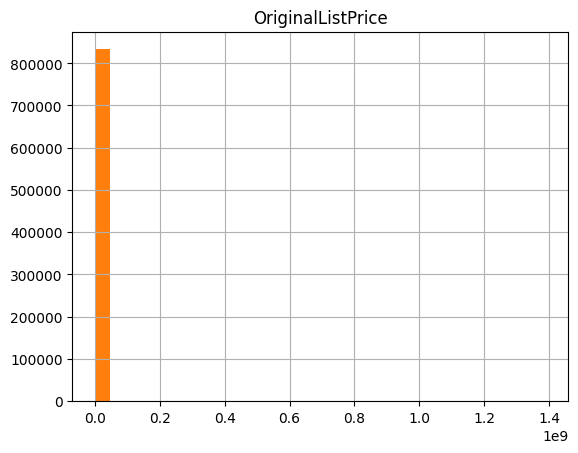

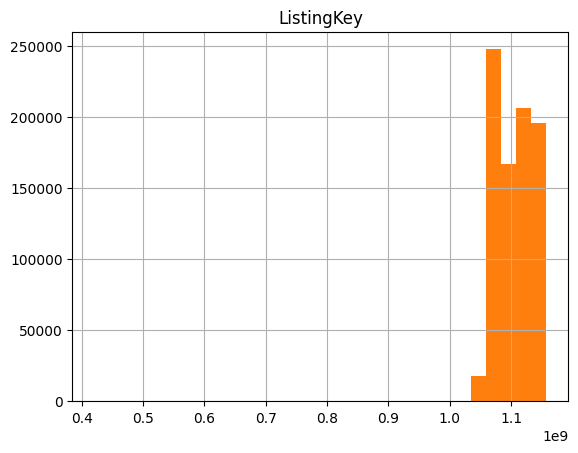

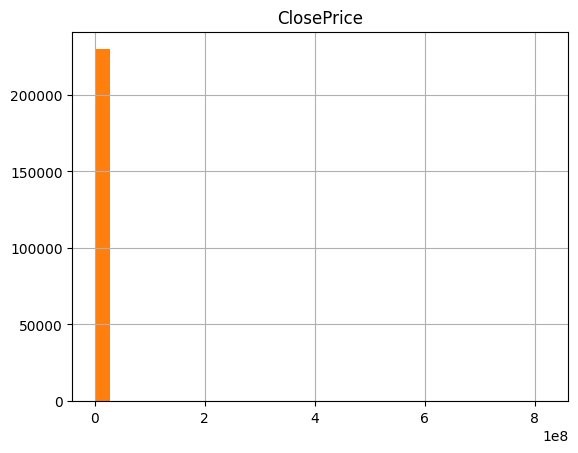

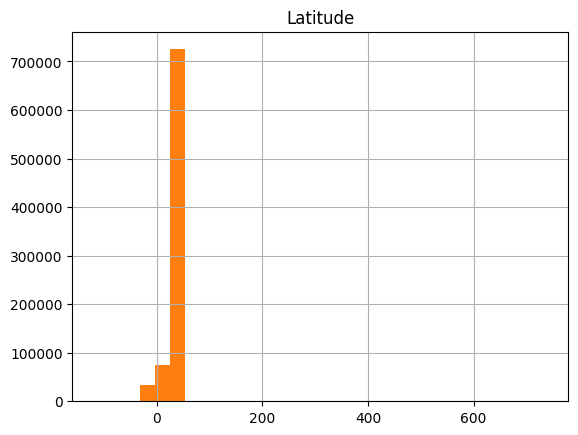

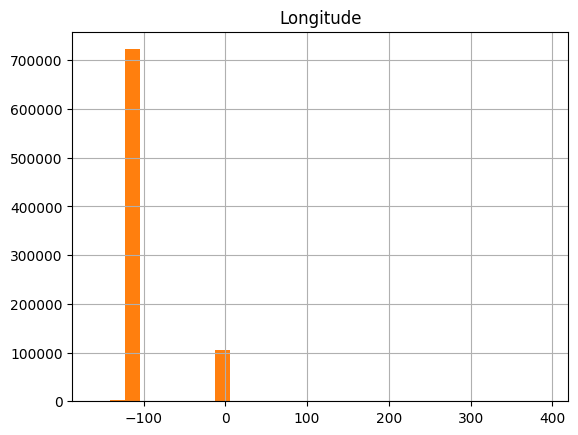

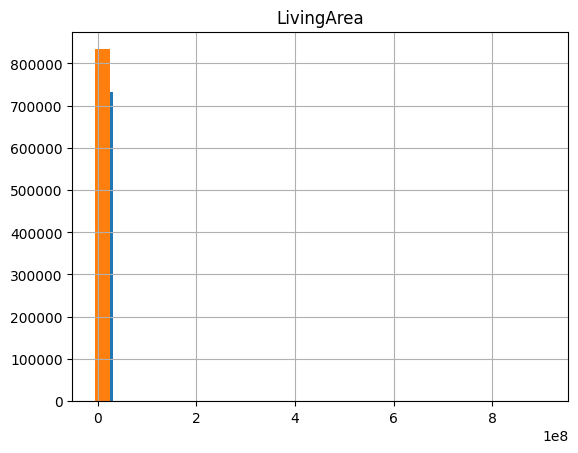

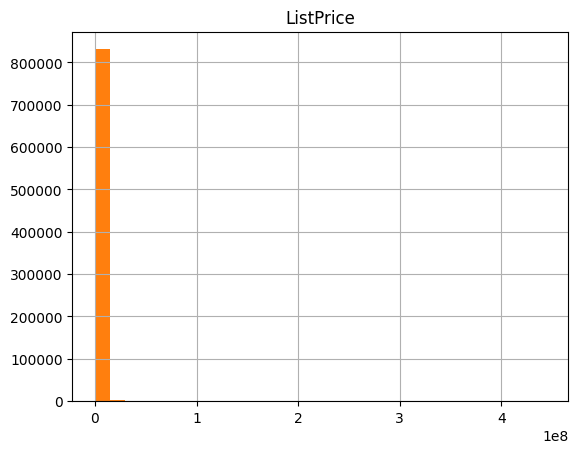

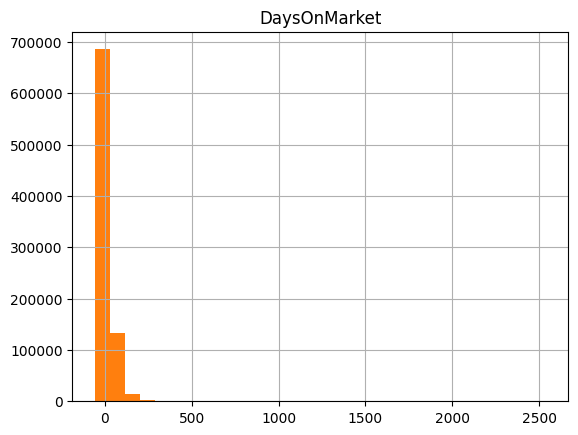

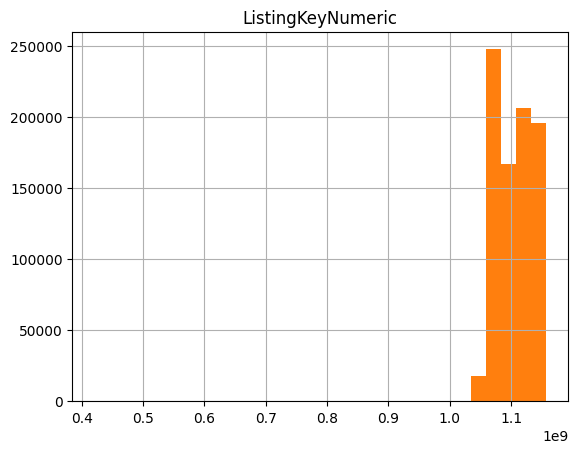

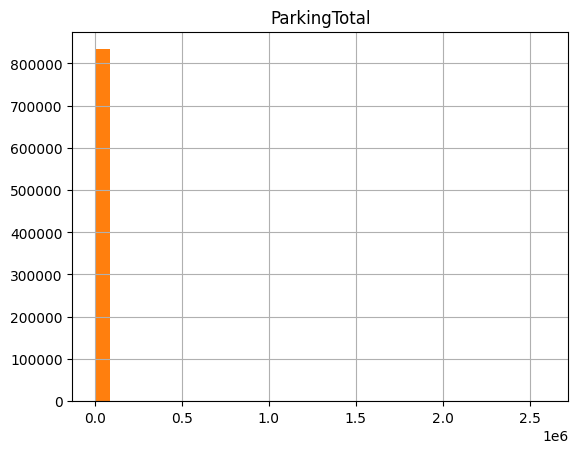

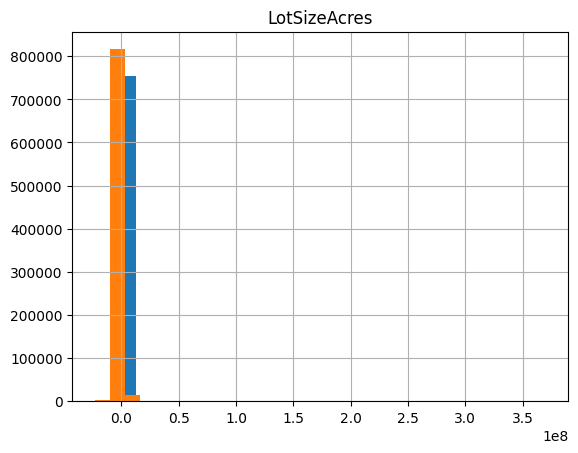

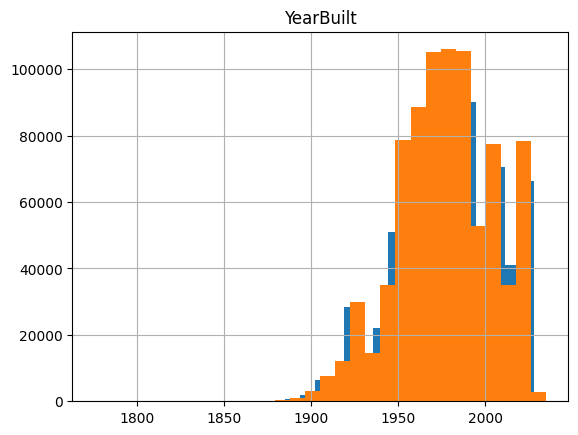

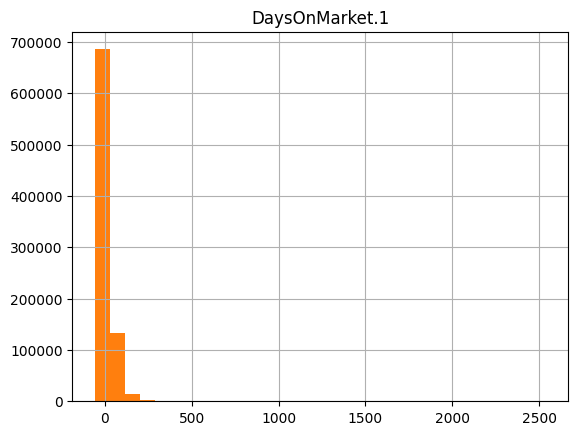

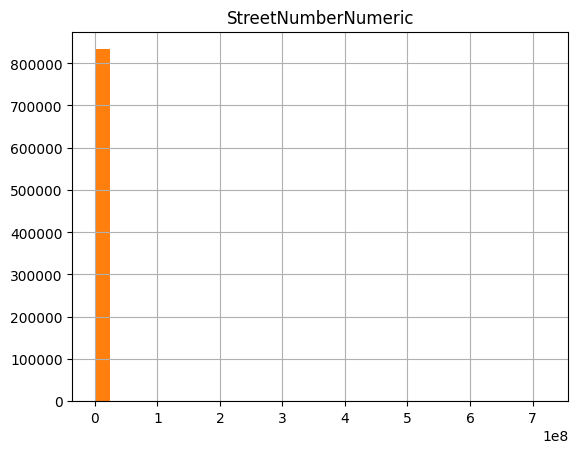

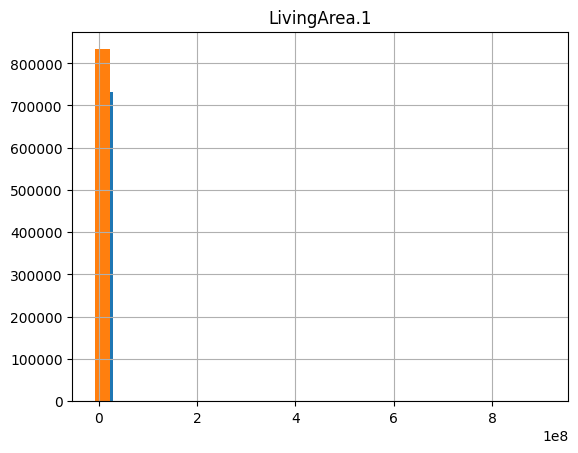

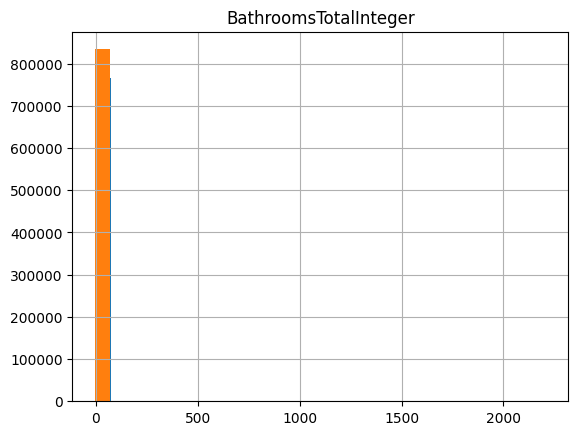

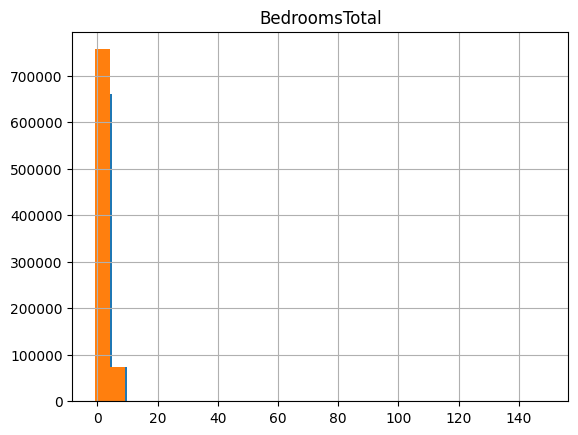

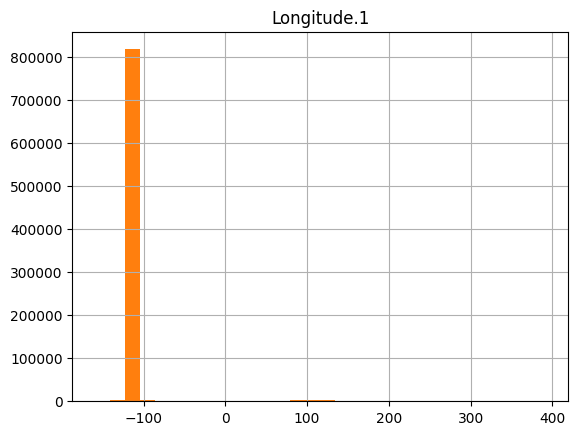

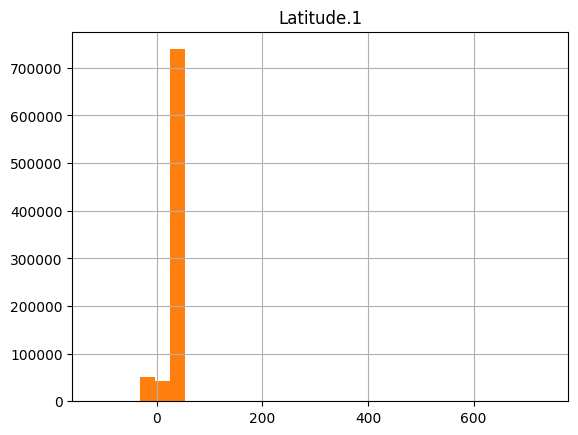

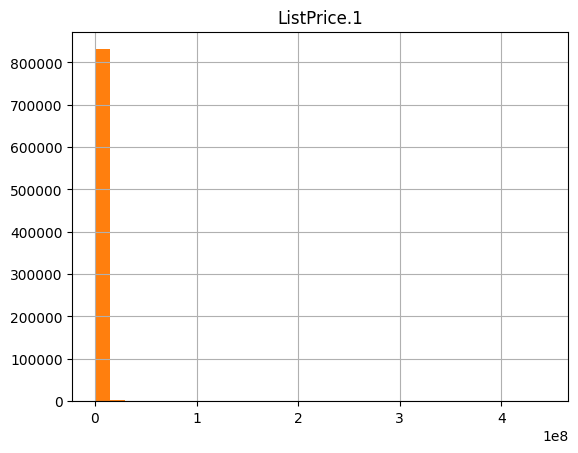

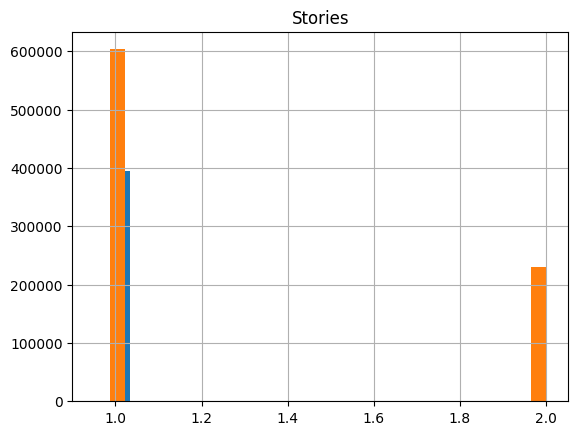

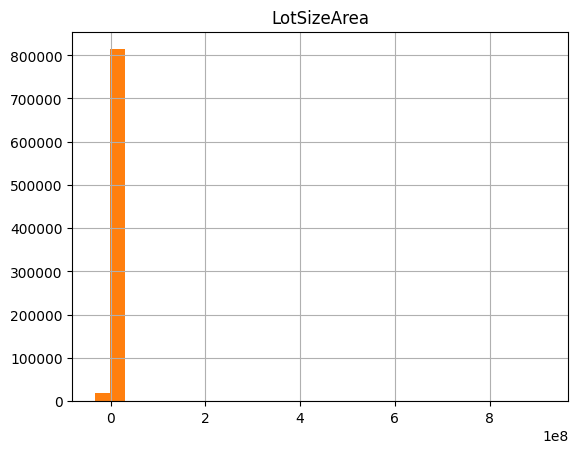

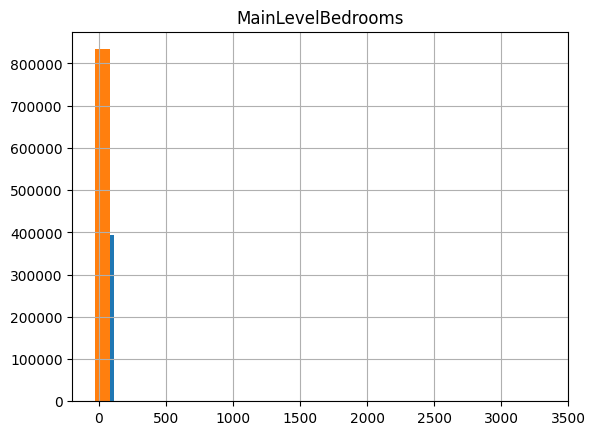

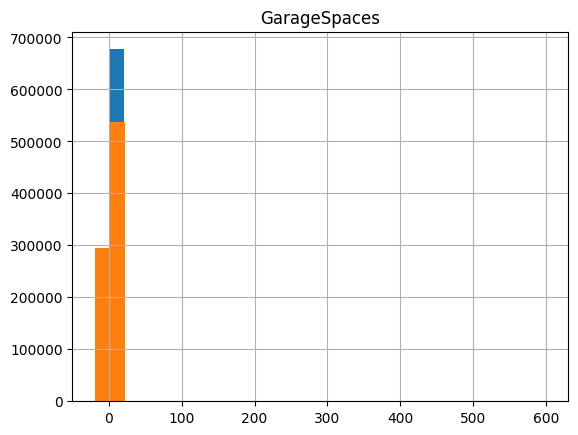

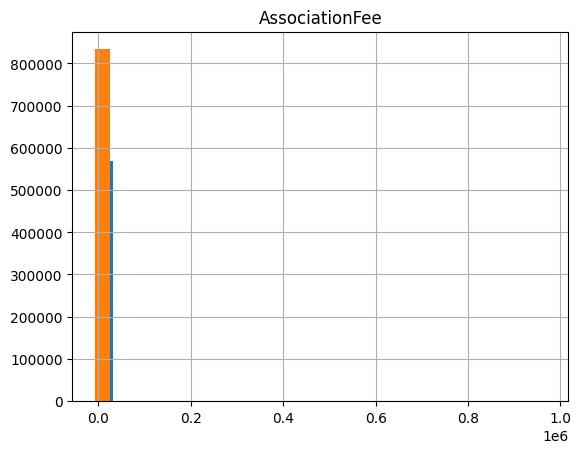

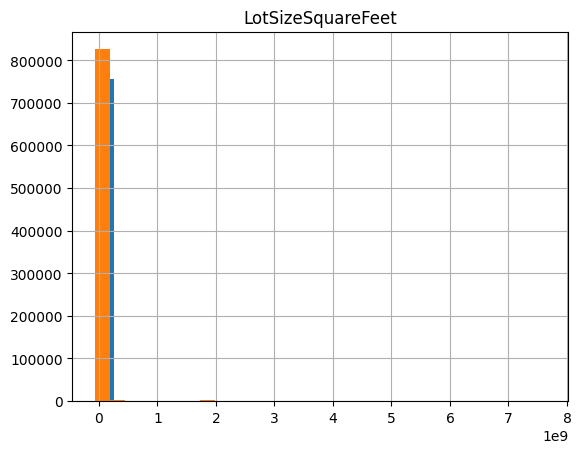

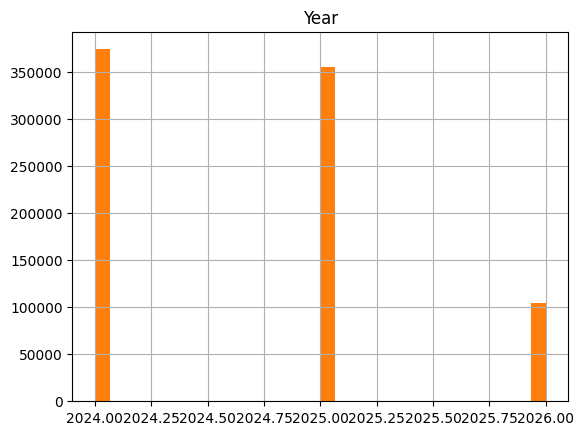

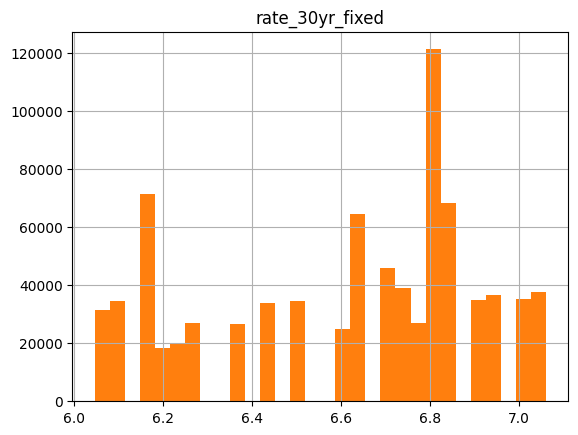

In [121]:
for col in continuous_columns:
    plt.figure()
    df_listings_cleaned[col].dropna().hist(bins=30)
    df_imputed[col].hist(bins=30)
    plt.title(col)
    plt.show()

In [64]:
for col in reduced_categorical_columns:
    print(f"\nColumn: {col}")
    print("Before:")
    print(df_listings_cleaned[col].value_counts(normalize=True, dropna=True))
    print("After:")
    print(df_imputed[col].value_counts(normalize=True))


Column: AttachedGarageYN
Before:
AttachedGarageYN
True     0.770465
False    0.229535
Name: proportion, dtype: float64
After:
AttachedGarageYN
True     0.559466
False    0.440534
Name: proportion, dtype: float64

Column: PropertySubType
Before:
PropertySubType
SingleFamilyResidence    0.639335
Condominium              0.197580
Townhouse                0.059710
Apartment                0.026375
Duplex                   0.022366
ManufacturedOnLand       0.012060
Quadruplex               0.007947
Triplex                  0.007779
MixedUse                 0.006874
Office                   0.003783
Retail                   0.003009
StockCooperative         0.002946
Industrial               0.001700
Cabin                    0.001424
Business                 0.001394
Studio                   0.000765
Warehouse                0.000719
RoomingHouse             0.000644
MultiFamily              0.000638
SpecialPurpose           0.000569
UnimprovedLand           0.000417
Agriculture             

In [65]:
df_listings_cleaned.isna().sum()

OriginalListPrice                0
ListingKey                       0
ListAgentEmail               71332
CloseDate                   582499
ClosePrice                  603953
ListAgentFirstName               0
ListAgentLastName                0
Latitude                    108404
Longitude                   107727
UnparsedAddress                  0
PropertyType                     0
LivingArea                  100952
ListPrice                        0
DaysOnMarket                     0
ListOfficeName                   0
ListAgentFullName                0
ListingKeyNumeric                0
MLSAreaMajor                 93897
CountyOrParish                   0
PropertyType.1                   0
MlsStatus                        0
ListAgentFirstName.1             0
AttachedGarageYN            283027
ParkingTotal                 49684
PropertySubType             100629
LotSizeAcres                 79474
SubdivisionName             555061
YearBuilt                    66207
DaysOnMarket.1      

In [66]:
continuous_columns

Index(['OriginalListPrice', 'ListingKey', 'ClosePrice', 'Latitude',
       'Longitude', 'LivingArea', 'ListPrice', 'DaysOnMarket',
       'ListingKeyNumeric', 'ParkingTotal', 'LotSizeAcres', 'YearBuilt',
       'DaysOnMarket.1', 'StreetNumberNumeric', 'LivingArea.1',
       'BathroomsTotalInteger', 'BedroomsTotal', 'Longitude.1', 'Latitude.1',
       'ListPrice.1', 'Stories', 'LotSizeArea', 'MainLevelBedrooms',
       'GarageSpaces', 'AssociationFee', 'LotSizeSquareFeet', 'Year',
       'rate_30yr_fixed'],
      dtype='str')

In [67]:
col = 'BedroomsTotal' # pick a column
mask = df_listings_cleaned[col].isna()

print(df_imputed.loc[mask, col].head(10))

15     1.718099
23     0.673720
28     0.387209
29     1.503567
35     2.243187
60     1.464455
62     2.276171
97     1.207408
99     1.689752
100    1.689752
Name: BedroomsTotal, dtype: float64


In [68]:
df_listings_cleaned[df_listings_cleaned['BedroomsTotal'] < 0]

,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,Latitude,Longitude,UnparsedAddress,...,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,UnparsedAddress.1,Year,year_month,rate_30yr_fixed


In [69]:
df_listings_cleaned[df_listings_cleaned['BedroomsTotal'].isna()]

,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,Latitude,Longitude,UnparsedAddress,...,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,UnparsedAddress.1,Year,year_month,rate_30yr_fixed
15,300000.0,1073259577,desiree@revelrealestate.com,NaN,NaN,Desiree,Estrada,33.903137,-118.234108,544 W Rosecrans Avenue,...,NaN,NaN,NaN,90222,NaN,1876.0,544 W Rosecrans Avenue,2024,2024-01,6.6425
23,105000.0,1073171653,chrisjcucchiara@gmail.com,2024-03-05,105000.0,Chris,Cucchiara,35.542360,-121.092195,0 Windsor Boulevard,...,False,NaN,NaN,93428,0.00,4025.0,0 Windsor Boulevard,2024,2024-01,6.6425
28,890000.0,1073151487,corey@murphyhousing.com,NaN,NaN,Corey,Murphy,38.401522,-122.716612,84 Bellevue Avenue,...,False,NaN,NaN,95407,0.00,62726.4,84 Bellevue Avenue,2024,2024-01,6.6425
29,70000.0,1073086862,vdsellshomes@gmail.com,NaN,NaN,Virginia,Diaz,34.554595,-117.777530,0 E Avenue S4 and 197th East,...,False,NaN,NaN,93591,0.00,217685.0,0 E Avenue S4 and 197th East,2024,2024-01,6.6425
35,2799000.0,1072836064,info@jodyclegg.com,NaN,NaN,Jody,Clegg,33.664144,-117.999418,627 7th Street,...,False,4.0,NaN,92648,0.00,5875.0,627 7th Street,2024,2024-01,6.6425
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
853706,2200000.0,1153002797,NaN,NaN,NaN,Niago,Wilson,34.047528,-118.572088,3515 Surfwood Road,...,False,NaN,NaN,90265,16.66,7408.0,3515 Surfwood Road,2026,2026-03,6.1775
853719,568000.0,1152638551,NaN,NaN,NaN,Amir,Aliloupour,37.825307,-122.195504,6030 Girvin Dr,...,NaN,NaN,NaN,94611,NaN,7663.0,6030 Girvin Dr,2026,2026-03,6.1775
853722,5950000.0,1152630261,NaN,NaN,NaN,John J.,Dutra,37.536000,-121.958411,40871 HIGH STREET,...,NaN,NaN,NaN,94538,NaN,53575.0,40871 HIGH STREET,2026,2026-03,6.1775
853749,6395000.0,1150511005,NaN,NaN,NaN,Arlene,Baxter,37.883215,-122.261440,2501 ROSE WALK,...,NaN,NaN,NaN,94708-1902,0.00,20000.0,2501 ROSE WALK,2026,2026-03,6.1775


In [70]:
df_imputed[df_imputed['BedroomsTotal'] < 0].shape

(384, 58)

In [122]:
print("Before correlation:")
print(df_listings_cleaned.corr(numeric_only=True))

print("After correlation:")
print(df_imputed.corr(numeric_only=True))

Before correlation:
                       OriginalListPrice  ListingKey  ClosePrice  Latitude  \
OriginalListPrice               1.000000    0.000472    0.060446  0.002623   
ListingKey                      0.000472    1.000000   -0.001900  0.042520   
ClosePrice                      0.060446   -0.001900    1.000000  0.015628   
Latitude                        0.002623    0.042520    0.015628  1.000000   
Longitude                      -0.011986   -0.026041   -0.018164 -0.316235   
LivingArea                      0.000034   -0.001488    0.120079  0.002388   
ListPrice                       0.338598   -0.004819    0.327927 -0.002304   
DaysOnMarket                    0.005156    0.134945   -0.007275  0.003221   
ListingKeyNumeric               0.000472    1.000000   -0.001900  0.042520   
ParkingTotal                   -0.000047   -0.001663   -0.000315 -0.000485   
LotSizeAcres                   -0.000200   -0.001723   -0.000635 -0.000679   
YearBuilt                       0.004380    

In [72]:
cat_columns = ['MLSAreaMajor', 'PropertySubType', 'SubdivisionName', 'PurchaseContractDate', 'HighSchoolDistrict']

In [73]:
cat_df_imputed[cat_columns].nunique()

MLSAreaMajor             1150
PropertySubType            34
SubdivisionName         21646
PurchaseContractDate      831
HighSchoolDistrict        456
dtype: int64

--------------------

In [124]:
#df_imputed.to_csv("../data/Listing/imputed_listings_data.csv", index=False)

In [3]:
df_imputed_listings = pd.read_csv("../data/Listing/imputed_listings_data.csv")
df_imputed_listings.head()

C:\Users\mayab\AppData\Local\Temp\ipykernel_23320\621416674.py:1: DtypeWarning: Columns (0: ListAgentEmail) have mixed types. Specify dtype option on import or set low_memory=False.
  df_imputed_listings = pd.read_csv("../data/Listing/imputed_listings_data.csv")


,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,Latitude,Longitude,UnparsedAddress,...,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,UnparsedAddress.1,Year,year_month,rate_30yr_fixed
0,90000.0,1075010398,miriamlara03@gmail.com,NaN,NaN,Miriam,Lara,34.097939,-117.909653,1045 N Azusa 61,...,False,2.000000,Covina Valley Unified,91722,0.000000,16410.198563,1045 N Azusa 61,2024,2024-01,6.6425
1,1340000.0,1074973329,haleh360@Gmail.com,NaN,NaN,Haleh,Dowlatshahi,34.052207,-118.408445,2220 Avenue Of The Stars 2704,...,False,0.986085,NaN,90067,2105.000000,177861.000000,2220 Avenue Of The Stars 2704,2024,2024-01,6.6425
2,2500000.0,1074954552,Reneechen@yourhomesoldguaranteed.com,NaN,NaN,Renee,Chen,33.496363,-117.691677,16 Palisades,...,False,3.000000,Capistrano Unified,92677,254.000000,5300.000000,16 Palisades,2024,2024-01,6.6425
3,3150000.0,1074936537,anader@dppre.com,NaN,NaN,Margaret,Nader,34.119345,-118.111254,1615 Waverly Road,...,False,2.000000,NaN,91108,73.829165,9404.000000,1615 Waverly Road,2024,2024-01,6.6425
4,3090000.0,1074917818,QIANYU0607@GMAIL.COM,NaN,NaN,QIANYU,GUAN,33.984057,-117.802819,2250 Indian Creek Road,...,False,4.000000,Walnut Valley Unified,91765,295.950000,58232.000000,2250 Indian Creek Road,2024,2024-01,6.6425


In [6]:
df_imputed_listings['YearBuilt'].isna().sum()

np.int64(0)

In [11]:
df_imputed_listings['NewConstructionYN'].value_counts()

NewConstructionYN
False    794114
True      39596
Name: count, dtype: int64

In [9]:
(df_imputed_listings['YearBuilt'] % 1 == 0).value_counts()

YearBuilt
True     767503
False     66207
Name: count, dtype: int64

In [7]:
df_imputed_listings['YearBuilt'].value_counts()

YearBuilt
2024.000000    18686
1989.000000    15053
2025.000000    13962
1979.000000    13604
1980.000000    13446
               ...  
1949.032543        1
1984.521288        1
1961.902605        1
1939.987340        1
1968.930906        1
Name: count, Length: 53897, dtype: int64

In [4]:
df_imputed_listings['SubdivisionName'].value_counts()

SubdivisionName
Other                7722
Not Applicable-1     7104
Not Applicable       3810
San Diego            3661
Not Listed           3504
                     ... 
06E                     1
Contadora               1
The Village Grove       1
CREEKS BEND             1
HAWTHORNE TERRAC        1
Name: count, Length: 21646, dtype: int64

In [126]:
df_imputed_listings.isna().sum()

OriginalListPrice                0
ListingKey                       0
ListAgentEmail               71332
CloseDate                   582499
ClosePrice                  603953
ListAgentFirstName               0
ListAgentLastName                0
Latitude                         0
Longitude                        0
UnparsedAddress                  0
PropertyType                     0
LivingArea                       0
ListPrice                        0
DaysOnMarket                     0
ListOfficeName                   0
ListAgentFullName                0
ListingKeyNumeric                0
MLSAreaMajor                 93897
CountyOrParish                   0
PropertyType.1                   0
MlsStatus                        0
ListAgentFirstName.1             0
AttachedGarageYN                 0
ParkingTotal                     0
PropertySubType                  0
LotSizeAcres                     0
SubdivisionName             555061
YearBuilt                        0
DaysOnMarket.1      

In [127]:
# Create a reference mapping of Names -> Emails
# Drop any rows that have missing emails so the map is 'clean'
email_lookup = df_imputed_listings.dropna(subset=['ListAgentEmail']).drop_duplicates(['ListAgentFirstName', 'ListAgentLastName'])

# Set the names as the index to make the 'lookup' possible
email_lookup = email_lookup.set_index(['ListAgentFirstName', 'ListAgentLastName'])['ListAgentEmail']

# Create a function to apply the logic
def fill_missing_emails(row):
    # Only try to fill if the current email is missing
    if pd.isna(row['ListAgentEmail']):
        # Look up the name in our reference map
        return email_lookup.get((row['ListAgentFirstName'], row['ListAgentLastName']), "None")
    return row['ListAgentEmail']

# Apply it to the dataframe
df_imputed_listings['ListAgentEmail'] = df_imputed_listings.apply(fill_missing_emails, axis=1)

In [128]:
df_imputed_listings['ListAgentEmail'].isna().sum()

np.int64(0)

In [129]:
(df_imputed_listings['ListAgentEmail'] == 'None').sum()

np.int64(3297)

From the code above, I noticed that there are no missing values for list agent's first and last names, so to determine their emails, I tried to look up any matches by full name to get the list agent's emails for the rows that are missing them. If there are no matches, those emails will be preserved by having a value of "None" (i.e. no email provided).

In [130]:
df_imputed_listings.isna().sum()

OriginalListPrice                0
ListingKey                       0
ListAgentEmail                   0
CloseDate                   582499
ClosePrice                  603953
ListAgentFirstName               0
ListAgentLastName                0
Latitude                         0
Longitude                        0
UnparsedAddress                  0
PropertyType                     0
LivingArea                       0
ListPrice                        0
DaysOnMarket                     0
ListOfficeName                   0
ListAgentFullName                0
ListingKeyNumeric                0
MLSAreaMajor                 93897
CountyOrParish                   0
PropertyType.1                   0
MlsStatus                        0
ListAgentFirstName.1             0
AttachedGarageYN                 0
ParkingTotal                     0
PropertySubType                  0
LotSizeAcres                     0
SubdivisionName             555061
YearBuilt                        0
DaysOnMarket.1      

In [131]:
df_imputed_listings.columns

Index(['OriginalListPrice', 'ListingKey', 'ListAgentEmail', 'CloseDate',
       'ClosePrice', 'ListAgentFirstName', 'ListAgentLastName', 'Latitude',
       'Longitude', 'UnparsedAddress', 'PropertyType', 'LivingArea',
       'ListPrice', 'DaysOnMarket', 'ListOfficeName', 'ListAgentFullName',
       'ListingKeyNumeric', 'MLSAreaMajor', 'CountyOrParish', 'PropertyType.1',
       'MlsStatus', 'ListAgentFirstName.1', 'AttachedGarageYN', 'ParkingTotal',
       'PropertySubType', 'LotSizeAcres', 'SubdivisionName', 'YearBuilt',
       'DaysOnMarket.1', 'StreetNumberNumeric', 'LivingArea.1', 'ListingId',
       'BathroomsTotalInteger', 'City', 'BedroomsTotal',
       'ContractStatusChangeDate', 'Longitude.1', 'PurchaseContractDate',
       'ListingContractDate', 'Latitude.1', 'ListPrice.1', 'StateOrProvince',
       'FireplaceYN', 'Stories', 'Levels', 'ListAgentLastName.1',
       'LotSizeArea', 'MainLevelBedrooms', 'NewConstructionYN', 'GarageSpaces',
       'HighSchoolDistrict', 'PostalCode'

Convert date fields to datetime format (CloseDate, PurchaseContractDate, ListingContractDate, ContractStatusChangeDate)

In [132]:
df_imputed_listings['CloseDate'] = pd.to_datetime(df_imputed_listings['CloseDate'], errors='coerce')

In [133]:
df_imputed_listings['PurchaseContractDate'] = pd.to_datetime(df_imputed_listings['PurchaseContractDate'], errors='coerce')

In [134]:
df_imputed_listings['ListingContractDate'] = pd.to_datetime(df_imputed_listings['ListingContractDate'], errors='coerce')

In [135]:
df_imputed_listings['ContractStatusChangeDate'] = pd.to_datetime(df_imputed_listings['ContractStatusChangeDate'], errors='coerce')

In [136]:
print(df_imputed_listings['PurchaseContractDate'].dtype)

datetime64[us]


Remove unnecessary or redundant columns

In [138]:
df_imputed_listings.columns

Index(['OriginalListPrice', 'ListingKey', 'ListAgentEmail', 'CloseDate',
       'ClosePrice', 'ListAgentFirstName', 'ListAgentLastName', 'Latitude',
       'Longitude', 'UnparsedAddress', 'PropertyType', 'LivingArea',
       'ListPrice', 'DaysOnMarket', 'ListOfficeName', 'ListAgentFullName',
       'ListingKeyNumeric', 'MLSAreaMajor', 'CountyOrParish', 'PropertyType.1',
       'MlsStatus', 'ListAgentFirstName.1', 'AttachedGarageYN', 'ParkingTotal',
       'PropertySubType', 'LotSizeAcres', 'SubdivisionName', 'YearBuilt',
       'DaysOnMarket.1', 'StreetNumberNumeric', 'LivingArea.1', 'ListingId',
       'BathroomsTotalInteger', 'City', 'BedroomsTotal',
       'ContractStatusChangeDate', 'Longitude.1', 'PurchaseContractDate',
       'ListingContractDate', 'Latitude.1', 'ListPrice.1', 'StateOrProvince',
       'FireplaceYN', 'Stories', 'Levels', 'ListAgentLastName.1',
       'LotSizeArea', 'MainLevelBedrooms', 'NewConstructionYN', 'GarageSpaces',
       'HighSchoolDistrict', 'PostalCode'

In [139]:
df_imputed_listings = df_imputed_listings.drop(columns=['PropertyType.1', 'ListAgentFirstName.1', 'DaysOnMarket.1', 'LivingArea.1', 'Longitude.1', 
                                                        'Latitude.1', 'ListPrice.1', 'ListAgentLastName.1', 'UnparsedAddress.1'])

In [140]:
df_imputed_listings.shape

(833710, 49)

In [178]:
(df_imputed_listings['OriginalListPrice'] == df_imputed_listings['ListPrice']).value_counts()

True     670462
False    163248
Name: count, dtype: int64

Handle missing values appropriately

In [141]:
df_imputed_listings.isna().sum()

OriginalListPrice                0
ListingKey                       0
ListAgentEmail                   0
CloseDate                   582499
ClosePrice                  603953
ListAgentFirstName               0
ListAgentLastName                0
Latitude                         0
Longitude                        0
UnparsedAddress                  0
PropertyType                     0
LivingArea                       0
ListPrice                        0
DaysOnMarket                     0
ListOfficeName                   0
ListAgentFullName                0
ListingKeyNumeric                0
MLSAreaMajor                 93897
CountyOrParish                   0
MlsStatus                        0
AttachedGarageYN                 0
ParkingTotal                     0
PropertySubType                  0
LotSizeAcres                     0
SubdivisionName             555061
YearBuilt                        0
StreetNumberNumeric              0
ListingId                        0
BathroomsTotalIntege

CloseDate, MLSAreaMajor, PurchaseContractDate, and HighSchoolDistrict are the features with missing values.

In [142]:
df_imputed_listings[['CloseDate', 'MLSAreaMajor', 'PurchaseContractDate', 'HighSchoolDistrict']].isna().mean()

CloseDate               0.698683
MLSAreaMajor            0.112625
PurchaseContractDate    0.564226
HighSchoolDistrict      0.392483
dtype: float64

Source: https://medium.com/@paghadalsneh/handling-missing-values-in-categorical-data-12b8afaa1be4

In [143]:
df_imputed_listings['MLSAreaMajor'].value_counts().head()

MLSAreaMajor
699 - Not Defined                     78579
SRCAR - Southwest Riverside County    34054
252 - Riverside                        8538
LAC - Lancaster                        6787
C14 - Santa Monica                     5559
Name: count, dtype: int64

Will impute using the mode for MLSAreaMajor because there is a lower portion of missing values

In [144]:
df_imputed_listings['MLSAreaMajor'] = df_imputed_listings['MLSAreaMajor'].fillna(df_imputed_listings['MLSAreaMajor'].mode()[0], inplace=True)

C:\Users\mayab\AppData\Local\Temp\ipykernel_36632\1592741207.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df_imputed_listings['MLSAreaMajor'] = df_imputed_listings['MLSAreaMajor'].fillna(df_imputed_listings['MLSAreaMajor'].mode()[0], inplace=True)


In [145]:
df_imputed_listings['MLSAreaMajor'].value_counts().head()

MLSAreaMajor
699 - Not Defined                     172476
SRCAR - Southwest Riverside County     34054
252 - Riverside                         8538
LAC - Lancaster                         6787
C14 - Santa Monica                      5559
Name: count, dtype: int64

In [146]:
df_imputed_listings['HighSchoolDistrict'].value_counts()

HighSchoolDistrict
Los Angeles Unified          53531
Other                        50211
Capistrano Unified           16489
Irvine Unified               11658
Saddleback Valley Unified     9463
                             ...  
Knightsen                        1
Leggett Valley Unified           1
Clear Creek                      1
Wishon                           1
Reeds Creek                      1
Name: count, Length: 456, dtype: int64

Will create a new category known as "Unknown" since there is a high number of missing values, which could signal that the missing values are important patterns themselves

In [147]:
df_imputed_listings['HighSchoolDistrict'] = df_imputed_listings['HighSchoolDistrict'].fillna("Unknown", inplace=True)

C:\Users\mayab\AppData\Local\Temp\ipykernel_36632\2407172197.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df_imputed_listings['HighSchoolDistrict'] = df_imputed_listings['HighSchoolDistrict'].fillna("Unknown", inplace=True)


In [148]:
df_imputed_listings['HighSchoolDistrict'].value_counts().head()

HighSchoolDistrict
Unknown                327217
Los Angeles Unified     53531
Other                   50211
Capistrano Unified      16489
Irvine Unified          11658
Name: count, dtype: int64

In [150]:
missing_close_date = df_imputed_listings[df_imputed_listings['CloseDate'].isna()]

In [151]:
missing_close_date.shape

(582499, 49)

In [152]:
missing_close_date[['HighSchoolDistrict', 'MLSAreaMajor', 'PurchaseContractDate', 'CloseDate']].head()

,HighSchoolDistrict,MLSAreaMajor,PurchaseContractDate,CloseDate
0,Covina Valley Unified,614 - Covina,NaT,NaT
1,Unknown,C05 - Westwood - Century City,2024-05-07,NaT
2,Capistrano Unified,LNSLT - Salt Creek,NaT,NaT
3,Unknown,655 - San Marino,NaT,NaT
4,Walnut Valley Unified,616 - Diamond Bar,NaT,NaT


In [153]:
missing_close_date['MLSAreaMajor'].value_counts().head()

MLSAreaMajor
699 - Not Defined                     105799
SRCAR - Southwest Riverside County     25572
252 - Riverside                         6076
LAC - Lancaster                         5639
C42 - Downtown L.A.                     4429
Name: count, dtype: int64

In [154]:
missing_close_date['HighSchoolDistrict'].value_counts().head()

HighSchoolDistrict
Unknown                244657
Los Angeles Unified     38433
Other                   25262
Capistrano Unified      10085
Irvine Unified           6499
Name: count, dtype: int64

In [155]:
missing_close_date['PurchaseContractDate'].isna().sum()

np.int64(464320)

In [156]:
missing_close_date['PurchaseContractDate'].isna().sum() / missing_close_date.shape[0]

np.float64(0.7971172482699541)

About 80% of missing close price entries have missing purchase contract date

This could signal that the missingness in close price is associated with another missing variable which is purchase contract date. So, the data could not be completely missing at random. 

In [157]:
pd.crosstab(
    df_imputed_listings['CloseDate'].isna(),
    df_imputed_listings['PurchaseContractDate'].isna(),
    normalize='index'
)

PurchaseContractDate,False,True
CloseDate,,
False,0.975793,0.024207
True,0.202883,0.797117


In [158]:
print(df_imputed_listings['PurchaseContractDate'].dtype)

datetime64[us]


In [159]:
print(df_imputed_listings['CloseDate'].dtype)

datetime64[us]


In [160]:
df_imputed_listings['no_purchase_date'] = df_imputed_listings['PurchaseContractDate'].isna()
df_imputed_listings['no_close_date'] = df_imputed_listings['CloseDate'].isna()

In [161]:
df_imputed_listings['PurchaseContractDate'].isna().sum()

np.int64(470401)

In [162]:
df_imputed_listings['PurchaseContractDate'].value_counts(dropna=False)

PurchaseContractDate
NaT           470401
2024-05-01      1207
2024-04-24      1115
2024-04-29      1055
2024-04-30      1049
               ...  
2028-02-27         1
2023-06-13         1
2026-12-11         1
2026-04-17         1
2026-04-30         1
Name: count, Length: 832, dtype: int64

In [163]:
df_imputed_listings['CloseDate'].value_counts(dropna=False)

CloseDate
NaT           582499
2024-03-29      1354
2024-04-30      1329
2025-10-31      1326
2025-11-21      1306
               ...  
2026-05-25         1
2026-06-09         1
2026-06-11         1
2027-01-30         1
2026-07-24         1
Name: count, Length: 917, dtype: int64

In [164]:
df_imputed_listings['no_purchase_date'].value_counts()

no_purchase_date
True     470401
False    363309
Name: count, dtype: int64

In [165]:
df_imputed_listings.shape

(833710, 51)

Keep the date variables with NaT to show those events were not observed or did not occur - I also created corresponding variables to measure this

ClosePrice

In [166]:
missing_close_price = df_imputed_listings[df_imputed_listings['ClosePrice'].isna()]

In [173]:
drop_close_price = df_imputed_listings.dropna(subset=['ClosePrice'])

In [175]:
drop_close_price.columns

Index(['OriginalListPrice', 'ListingKey', 'ListAgentEmail', 'CloseDate',
       'ClosePrice', 'ListAgentFirstName', 'ListAgentLastName', 'Latitude',
       'Longitude', 'UnparsedAddress', 'PropertyType', 'LivingArea',
       'ListPrice', 'DaysOnMarket', 'ListOfficeName', 'ListAgentFullName',
       'ListingKeyNumeric', 'MLSAreaMajor', 'CountyOrParish', 'MlsStatus',
       'AttachedGarageYN', 'ParkingTotal', 'PropertySubType', 'LotSizeAcres',
       'SubdivisionName', 'YearBuilt', 'StreetNumberNumeric', 'ListingId',
       'BathroomsTotalInteger', 'City', 'BedroomsTotal',
       'ContractStatusChangeDate', 'PurchaseContractDate',
       'ListingContractDate', 'StateOrProvince', 'FireplaceYN', 'Stories',
       'Levels', 'LotSizeArea', 'MainLevelBedrooms', 'NewConstructionYN',
       'GarageSpaces', 'HighSchoolDistrict', 'PostalCode', 'AssociationFee',
       'LotSizeSquareFeet', 'Year', 'year_month', 'rate_30yr_fixed',
       'no_purchase_date', 'no_close_date'],
      dtype='str')

In [176]:
drop_close_price[['OriginalListPrice', 'ListPrice','ClosePrice']]

,OriginalListPrice,ListPrice,ClosePrice
10,1249888.0,1249888.0,1262555.0
18,650000.0,650000.0,650000.0
22,105000.0,105000.0,105000.0
23,1025000.0,1025000.0,962500.0
25,725000.0,725000.0,725000.0
...,...,...,...
833652,4500.0,4500.0,4500.0
833656,779000.0,779000.0,761000.0
833659,4975.0,4975.0,4995.0
833683,2295000.0,2295000.0,2380000.0


In [179]:
df_imputed_listings['ClosePrice'] = pd.to_numeric(df_imputed_listings['ClosePrice'], errors='coerce')

In [182]:
df_imputed_listings['ClosePrice_Missing'] = df_imputed_listings['ClosePrice'].isna().astype(int)

In [183]:
df_imputed_listings['ClosePrice_Missing'].value_counts()

ClosePrice_Missing
1    603953
0    229757
Name: count, dtype: int64

Since there is a high volume of missing values in ClosePrice and instead of dropping the variable completely, I want to preserve it, so I decided to create a close price missing variable as the missingness could be a real indicator of what is occurring behind the scenes with housing contracts and such.

In [ ]:
df_imputed_listings.isna().sum().sum()

np.int64(2211914)

In [193]:
df_imputed_listings.notna().sum().sum()

np.int64(41141006)

In [194]:
df_imputed_listings.isna().sum().sum() / df_imputed_listings.notna().sum().sum()

np.float64(0.05376421762754173)

In the end, there are 2,211,914 missing values. So from the entire dataset, about 5-6% of it are missing values. 

Ensure numeric fields are properly typed

In [42]:
df_imputed_listings.info()

<class 'pandas.DataFrame'>
RangeIndex: 833710 entries, 0 to 833709
Data columns (total 51 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   OriginalListPrice         833710 non-null  float64       
 1   ListingKey                833710 non-null  int64         
 2   ListAgentEmail            833710 non-null  str           
 3   CloseDate                 251211 non-null  datetime64[us]
 4   ClosePrice                833710 non-null  float64       
 5   ListAgentFirstName        833710 non-null  str           
 6   ListAgentLastName         833710 non-null  str           
 7   Latitude                  833710 non-null  float64       
 8   Longitude                 833710 non-null  float64       
 9   UnparsedAddress           833710 non-null  str           
 10  PropertyType              833710 non-null  str           
 11  LivingArea                833710 non-null  float64       
 12  ListPrice    

### UPDATE: No longer will use LightGBM

Remove or flag invalid numeric values: ClosePrice <=0, LivingArea <=0, DaysOnMarket < 0, negative Bedrooms or Bathrooms


Do some negative values and initial cleaning before the LightGBM imputation

### **NEXT STEPS (For the rest of Week 3)**

- Handle the other missing values for the categorical variables
- Conduct the missing values and outlier cleaning for sold_transactions

#### **Outlier Cleaning**

In [289]:
df_listings.columns

Index(['OriginalListPrice', 'ListingKey', 'ListAgentEmail', 'CloseDate',
       'ClosePrice', 'ListAgentFirstName', 'ListAgentLastName', 'Latitude',
       'Longitude', 'UnparsedAddress', 'PropertyType', 'LivingArea',
       'ListPrice', 'DaysOnMarket', 'ListOfficeName', 'BuyerOfficeName',
       'CoListOfficeName', 'ListAgentFullName', 'CoListAgentFirstName',
       'CoListAgentLastName', 'BuyerAgentMlsId', 'BuyerAgentFirstName',
       'BuyerAgentLastName', 'FireplacesTotal', 'AssociationFeeFrequency',
       'AboveGradeFinishedArea', 'ListingKeyNumeric', 'MLSAreaMajor',
       'TaxAnnualAmount', 'CountyOrParish', 'PropertyType.1', 'MlsStatus',
       'ElementarySchool', 'ListAgentFirstName.1', 'AttachedGarageYN',
       'ParkingTotal', 'BuilderName', 'PropertySubType', 'LotSizeAcres',
       'SubdivisionName', 'BuyerOfficeAOR', 'YearBuilt', 'DaysOnMarket.1',
       'BuyerAgencyCompensationType', 'StreetNumberNumeric', 'LivingArea.1',
       'ListingId', 'BathroomsTotalInteger', 'Cit

Removing and inspecting negative values

In [290]:
neg_counts = (df_listings.select_dtypes(include='number') < 0).sum()

In [291]:
neg_counts[neg_counts > 0]

Latitude               7
Longitude         742263
DaysOnMarket          37
ParkingTotal         177
DaysOnMarket.1        37
Longitude.1       742263
Latitude.1             7
dtype: int64

In [292]:
(neg_counts[neg_counts > 0] / df_listings.shape[0] * 100).sort_values(ascending=False)

Longitude         86.941086
Longitude.1       86.941086
ParkingTotal       0.020732
DaysOnMarket.1     0.004334
DaysOnMarket       0.004334
Latitude           0.000820
Latitude.1         0.000820
dtype: float64

In [293]:
continuous_columns = df_listings.select_dtypes(include=['int64', 'float64']).columns

In [294]:
df_listings[continuous_columns].corr(method = "spearman").round(2)

,OriginalListPrice,ListingKey,ClosePrice,Latitude,Longitude,LivingArea,ListPrice,DaysOnMarket,FireplacesTotal,AboveGradeFinishedArea,...,CoveredSpaces,Stories,LotSizeArea,MainLevelBedrooms,GarageSpaces,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,Year,rate_30yr_fixed
OriginalListPrice,1.00,-0.01,0.99,0.00,-0.13,0.49,1.00,0.05,NaN,NaN,...,NaN,0.17,0.05,0.08,0.34,0.26,0.04,NaN,0.00,0.02
ListingKey,-0.01,1.00,-0.01,0.03,-0.04,-0.01,-0.01,0.08,NaN,NaN,...,NaN,-0.00,0.01,-0.01,-0.01,0.01,0.01,NaN,0.91,-0.64
ClosePrice,0.99,-0.01,1.00,0.04,-0.11,0.46,1.00,-0.12,NaN,NaN,...,NaN,0.10,0.04,0.14,0.33,0.32,0.04,NaN,-0.00,0.01
Latitude,0.00,0.03,0.04,1.00,-0.73,-0.00,0.00,0.01,NaN,NaN,...,NaN,-0.05,0.08,0.18,-0.04,-0.15,0.08,NaN,0.03,-0.02
Longitude,-0.13,-0.04,-0.11,-0.73,1.00,0.01,-0.13,-0.04,NaN,NaN,...,NaN,-0.02,0.00,-0.06,0.05,0.01,0.03,NaN,-0.04,0.02
LivingArea,0.49,-0.01,0.46,-0.00,0.01,1.00,0.49,0.02,NaN,NaN,...,NaN,0.41,0.16,0.01,0.61,-0.06,0.16,NaN,-0.00,0.01
ListPrice,1.00,-0.01,1.00,0.00,-0.13,0.49,1.00,0.04,NaN,NaN,...,NaN,0.17,0.05,0.08,0.35,0.26,0.04,NaN,0.00,0.02
DaysOnMarket,0.05,0.08,-0.12,0.01,-0.04,0.02,0.04,1.00,NaN,NaN,...,NaN,0.01,-0.03,-0.02,0.00,0.10,-0.05,NaN,0.05,-0.12
FireplacesTotal,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AboveGradeFinishedArea,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Text(0.5, 1.0, 'Correlation matrix')

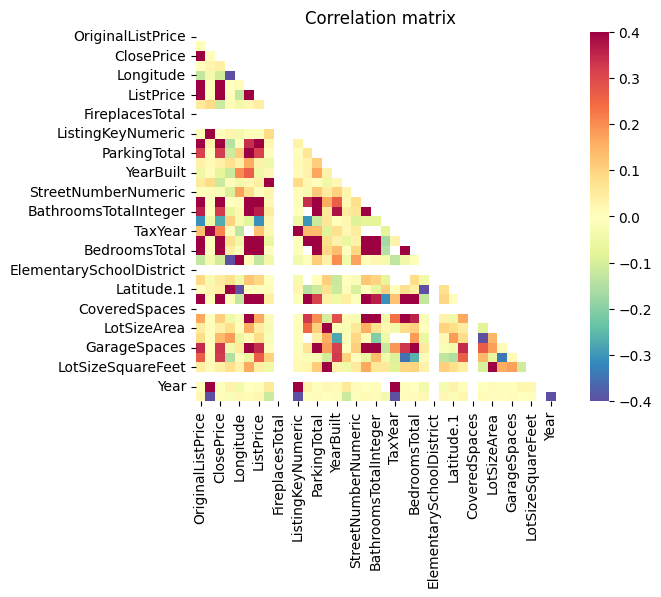

In [295]:
corrs =df_listings[continuous_columns].corr(method = "spearman")
mask = np.zeros_like(corrs)
mask[np.triu_indices_from(mask)] = True
sns.heatmap(corrs, cmap='Spectral_r', mask=mask, square=True, vmin=-.4, vmax=.4)
plt.title('Correlation matrix')

In [296]:
# 1. Calculate the correlation matrix
corr_matrix = df_listings[continuous_columns].corr(method="spearman").round(2)

# 2. Stack the matrix and filter by absolute value
# We use .abs() to include both moderate positive and moderate negative correlations
moderate_corr = corr_matrix.stack()
moderate_corr = moderate_corr[(moderate_corr.abs() >= 0.3) & (moderate_corr.abs() < 0.7)]

# 3. Display the results
print(moderate_corr)

OriginalListPrice  LivingArea               0.49
                   TaxAnnualAmount          0.51
                   ParkingTotal             0.31
                   LivingArea.1             0.49
                   BathroomsTotalInteger    0.36
                                            ... 
Year               rate_30yr_fixed         -0.48
rate_30yr_fixed    ListingKey              -0.64
                   ListingKeyNumeric       -0.64
                   TaxYear                 -0.42
                   Year                    -0.48
Length: 138, dtype: float64


LotSizeArea           

About 5% are negative

In [ ]:
neg_LotSizeArea = df_listings[df_listings['LotSizeArea'] < 0]
neg_LotSizeArea.head()

,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,Latitude,Longitude,UnparsedAddress,...,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,Year,year_month,rate_30yr_fixed,no_purchase_date,no_close_date,ClosePrice_Missing
0,90000.0,1075010398,miriamlara03@gmail.com,NaT,NaN,Miriam,Lara,34.097939,-117.909653,1045 N Azusa 61,...,Covina Valley Unified,91722,0.0,1.641020e+04,2024,2024-01,6.6425,True,True,1
10,1249888.0,1073295259,sandra.mcfetridge@gmail.com,2024-05-01,1262555.0,Sandra,McFetridge,33.477414,-117.664879,33450 Paseo El Lazo,...,Capistrano Unified,92675,395.0,9.879081e+06,2024,2024-01,6.6425,False,False,0
19,445000.0,1073212914,susanbwalters@yahoo.com,NaT,NaN,Susan,Walters,33.604039,-117.704258,159 Avenida Majorca A,...,Saddleback Valley Unified,92637,663.0,1.000488e+07,2024,2024-01,6.6425,True,True,1
21,699000.0,1073185216,realtordelcie@gmail.com,NaT,NaN,Delcie,Pecoraro,32.625488,-116.974079,1927 Caminito Alcala,...,Chula Vista Elementary,91913,325.0,1.641020e+04,2024,2024-01,6.6425,False,True,1
47,398000.0,1071220542,HanyMaldonado@bhhscal.com,NaT,NaN,Hany,Maldonado,33.203875,-117.339275,432 Edgehill Lane 65,...,Oceanside Unified,92054,342.0,1.126487e+07,2024,2024-01,6.6425,False,True,1


In [206]:
neg_LotSizeArea.head()

,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,Latitude,Longitude,UnparsedAddress,...,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,Year,year_month,rate_30yr_fixed,no_purchase_date,no_close_date,ClosePrice_Missing
0,90000.0,1075010398,miriamlara03@gmail.com,NaT,NaN,Miriam,Lara,34.097939,-117.909653,1045 N Azusa 61,...,Covina Valley Unified,91722,0.0,1.641020e+04,2024,2024-01,6.6425,True,True,1
10,1249888.0,1073295259,sandra.mcfetridge@gmail.com,2024-05-01,1262555.0,Sandra,McFetridge,33.477414,-117.664879,33450 Paseo El Lazo,...,Capistrano Unified,92675,395.0,9.879081e+06,2024,2024-01,6.6425,False,False,0
19,445000.0,1073212914,susanbwalters@yahoo.com,NaT,NaN,Susan,Walters,33.604039,-117.704258,159 Avenida Majorca A,...,Saddleback Valley Unified,92637,663.0,1.000488e+07,2024,2024-01,6.6425,True,True,1
21,699000.0,1073185216,realtordelcie@gmail.com,NaT,NaN,Delcie,Pecoraro,32.625488,-116.974079,1927 Caminito Alcala,...,Chula Vista Elementary,91913,325.0,1.641020e+04,2024,2024-01,6.6425,False,True,1
47,398000.0,1071220542,HanyMaldonado@bhhscal.com,NaT,NaN,Hany,Maldonado,33.203875,-117.339275,432 Edgehill Lane 65,...,Oceanside Unified,92054,342.0,1.126487e+07,2024,2024-01,6.6425,False,True,1


In [209]:
df_imputed_listings['LotSizeArea'].describe()

count    8.337100e+05
mean     2.310597e+05
std      3.385410e+06
min     -3.314088e+07
25%      4.356000e+03
50%      7.200000e+03
75%      1.524600e+04
max      9.187423e+08
Name: LotSizeArea, dtype: float64

In [ ]:
(df_listings['LotSizeArea'] == 0).value_counts() # originally 

LotSizeArea
False    835280
True      18474
Name: count, dtype: int64

In [ ]:
(df_imputed_listings['LotSizeArea'] == 0).value_counts() # after LightGBM imputation

LotSizeArea
False    815526
True      18184
Name: count, dtype: int64

In [207]:
neg_LotSizeArea['LotSizeArea']

0        -5.499475e+05
10       -9.890475e+06
19       -3.720791e+06
21       -2.818655e+04
47       -2.465492e+05
              ...     
833677   -2.420155e+05
833684   -5.234601e+05
833688   -1.360091e+05
833697   -1.005988e+05
833698   -3.947481e+05
Name: LotSizeArea, Length: 42438, dtype: float64

In [226]:
from sklearn.linear_model import LinearRegression

valid = df_imputed_listings[df_imputed_listings['LotSizeArea'] >= 0]

X_train = valid[['LotSizeSquareFeet']]
y_train = valid['LotSizeArea']

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [227]:
mask = df_imputed_listings['LotSizeArea'] < 0

df_imputed_listings.loc[mask, 'LotSizeArea'] = model.predict(
    df_imputed_listings.loc[mask, ['LotSizeSquareFeet']]
)

In [229]:
neg_LotSizeArea_new = df_imputed_listings[df_imputed_listings['LotSizeArea'] < 0]
neg_LotSizeArea_new.shape

(0, 52)

In [228]:
df_imputed_listings['LotSizeArea'].describe()

count    8.337100e+05
mean     3.673273e+05
std      3.257577e+06
min      0.000000e+00
25%      5.153250e+03
50%      7.606000e+03
75%      2.257700e+04
max      9.187423e+08
Name: LotSizeArea, dtype: float64

LotSizeAcres             

In [235]:
df_imputed_listings['LotSizeAcres']

0        -6.292809e+06
1         4.083100e+00
2         1.217000e-01
3         2.159000e-01
4         1.336800e+00
              ...     
833705    4.591000e-01
833706    7.000000e-02
833707    2.903000e-01
833708    1.651000e-01
833709    1.651000e-01
Name: LotSizeAcres, Length: 833710, dtype: float64

In [233]:
neg_LotSizeAcres = df_imputed_listings[df_imputed_listings['LotSizeAcres'] < 0]
neg_LotSizeAcres['LotSizeAcres']

0        -6.292809e+06
21       -3.364811e+05
32       -1.613434e+06
86       -4.681388e+06
92       -7.056093e+05
              ...     
833658   -1.324812e+05
833677   -1.497508e+06
833684   -3.520000e+06
833688   -1.296158e+06
833697   -6.733356e+05
Name: LotSizeAcres, Length: 39361, dtype: float64

Remove negative values LotSizeAcres

BathroomsTotalInteger     

In [239]:
df_imputed_listings['BathroomsTotalInteger']

0         1.0
1         2.0
2         3.0
3         4.0
4         9.0
         ... 
833705    0.0
833706    2.0
833707    5.0
833708    2.0
833709    0.0
Name: BathroomsTotalInteger, Length: 833710, dtype: float64

In [ ]:
df_imputed_listings['BathroomsTotalInteger'].value_counts()

BathroomsTotalInteger
 2.000000    298931
 3.000000    223252
 1.000000    107111
 4.000000     59555
 0.000000     31183
              ...  
-0.002884         1
 0.644151         1
-0.007513         1
 0.042834         1
 0.709292         1
Name: count, Length: 25944, dtype: int64

In [236]:
neg_Bathrooms = df_imputed_listings[df_imputed_listings['BathroomsTotalInteger'] < 0]
neg_Bathrooms['BathroomsTotalInteger']

22       -0.012054
28       -0.010813
58       -0.009242
95       -0.015834
96       -0.015834
            ...   
833391   -0.014121
833398   -0.010727
833412   -0.153183
833425   -0.027399
833458   -0.003788
Name: BathroomsTotalInteger, Length: 27701, dtype: float64

In [247]:
df_imputed_listings = df_imputed_listings[df_imputed_listings['BathroomsTotalInteger'] % 1 == 0]

In [250]:
df_listings['BathroomsTotalInteger'].isna().sum()

np.int64(69948)

In [251]:
df_listings['BathroomsTotalInteger'].value_counts()

BathroomsTotalInteger
2.0      304962
3.0      227465
1.0      108827
4.0       60928
0.0       34021
          ...  
87.0          1
123.0         1
65.0          1
149.0         1
55.0          1
Name: count, Length: 87, dtype: int64

In [248]:
df_imputed_listings['BathroomsTotalInteger'].value_counts()

BathroomsTotalInteger
2.0      298931
3.0      223252
1.0      107111
4.0       59555
0.0       31183
          ...  
87.0          1
123.0         1
65.0          1
149.0         1
55.0          1
Name: count, Length: 86, dtype: int64

In [255]:
df_listings['BathroomsTotalInteger'].shape

(853754,)

In [256]:
df_listings['BathroomsTotalInteger'].isna().sum()

np.int64(69948)

In [257]:
69948 / 853754

0.08192992360797138

In [258]:
853754 - 69948

783806

In [254]:
df_imputed_listings['BathroomsTotalInteger'].shape

(766645,)

In [253]:
(df_imputed_listings['BathroomsTotalInteger'] < 0).value_counts()

BathroomsTotalInteger
False    766645
Name: count, dtype: int64

Removes values that are not integers

AssociationFee            

In [259]:
neg_AssociationFee = df_imputed_listings[df_imputed_listings['AssociationFee'] < 0]

In [260]:
neg_AssociationFee.head()

,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,Latitude,Longitude,UnparsedAddress,...,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,Year,year_month,rate_30yr_fixed,no_purchase_date,no_close_date,ClosePrice_Missing
151,1900000.0,1065145021,ainsleyhughes@kw.com,NaT,NaN,Ainsley,Hughes,34.438236,-119.136944,12246 Sisar Road,...,Unknown,93023,-239.479050,62290.8,2024,2024-01,6.6425,True,True,1
223,899000.0,1063528331,absea@comcast.net,2024-03-19,810000.0,A.B.,Priceman DRE 0126...,39.383806,-123.789254,31530 Emerald Drive,...,Unknown,95437,-658.956960,34848.0,2024,2024-01,6.6425,False,False,0
340,648000.0,1062101655,robert.bilheimer@evrealestate.com,2024-05-07,755000.0,Robert,Bilheimer,34.043397,-118.218479,338 S State Street,...,Unknown,90033,-11.432688,4397.0,2024,2024-01,6.6425,False,False,0
547,999000.0,1061617422,kerry.kimble@theagencyre.com,2024-01-30,1130000.0,Kerry,Kimble,34.070215,-118.258618,1131 W Kensington Road,...,Unknown,90026,-1.693154,7128.0,2024,2024-01,6.6425,False,False,0
696,949000.0,1061311996,victoria.ascarrunz@compass.com,2024-04-18,1045000.0,Victoria,Ascarrunz,34.125965,-118.185076,6134 Hillandale Drive,...,Unknown,90042,-8.325558,6751.0,2024,2024-01,6.6425,False,False,0


In [261]:
neg_AssociationFee.shape

(5473, 52)

In [262]:
df_imputed_listings.shape

(766645, 52)

In [268]:
df_listings['AssociationFee'].describe()

count    577819.000000
mean        205.309153
std        2060.895511
min           0.000000
25%           0.000000
50%           0.000000
75%         311.000000
max      968348.000000
Name: AssociationFee, dtype: float64

In [270]:
df_listings['AssociationFee'].value_counts()

AssociationFee
0.00       328027
400.00       2859
300.00       2814
450.00       2581
350.00       2503
            ...  
643.04          1
1046.01         1
16.66           1
313.87          1
920.84          1
Name: count, Length: 12908, dtype: int64

In [271]:
df_imputed_listings['AssociationFee'].value_counts()

AssociationFee
0.000000      281956
400.000000      2770
300.000000      2735
450.000000      2511
350.000000      2442
               ...  
188.379141         1
409.316502         1
920.840000         1
956.631414         1
240.509522         1
Name: count, Length: 214899, dtype: int64

In [266]:
neg_AssociationFee['AssociationFee'].describe()

count    5473.000000
mean     -329.118461
std       635.096537
min     -7691.972089
25%      -363.049411
50%      -100.682428
75%       -12.331977
max        -0.007925
Name: AssociationFee, dtype: float64

Remove the negative values of Association Fee

MainLevelBedrooms         

In [272]:
neg_MainLevelBedrooms = df_imputed_listings[df_imputed_listings['MainLevelBedrooms'] < 0]

In [274]:
neg_MainLevelBedrooms.head()

,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,Latitude,Longitude,UnparsedAddress,...,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,Year,year_month,rate_30yr_fixed,no_purchase_date,no_close_date,ClosePrice_Missing
45,8995000.0,1071381267,samshakerchi@gmail.com,NaT,NaN,Sam,Shakerchi,34.025002,-118.357265,5112 W Jefferson Boulevard,...,Unknown,90016,4441.786504,33340.0,2024,2024-01,6.6425,True,True,1
122,1345000.0,1065254542,chris@sdishome.com,NaT,NaN,Chris,Jensen,1.591095,-12.654157,550 54 Ritchey St,...,Unknown,92114,0.000000,4769.0,2024,2024-01,6.6425,False,True,1
335,2559000.0,1062112807,fioraaston@gmail.com,2024-03-05,2559000.0,Fiora,Aston,34.035450,-118.507100,939 San Vicente Boulevard,...,Unknown,90402,509.501218,7670.0,2024,2024-01,6.6425,False,False,0
804,1600000.0,1061225796,allisonm1031@gmail.com,2024-03-18,1710000.0,Allison,Marklein,4.829315,-2.778580,1720 1728 Evergreen St,...,Unknown,92106,0.000000,4457.0,2024,2024-01,6.6425,False,False,0
1002,800000.0,1060233957,brandonhills.re@gmail.com,2024-04-29,680000.0,Brandon,Hills,-4.918095,-10.593112,1341 Higgins St.,...,Unknown,92058,301.027138,5142.0,2024,2024-01,6.6425,False,False,0


In [276]:
neg_MainLevelBedrooms.shape

(16072, 52)

In [278]:
df_listings['MainLevelBedrooms'].value_counts().head()

MainLevelBedrooms
1.0    102104
3.0     95325
2.0     76941
0.0     70003
4.0     41696
Name: count, dtype: int64

In [281]:
df_imputed_listings['MainLevelBedrooms'].value_counts()

MainLevelBedrooms
1.000000    101876
3.000000     95103
2.000000     76785
0.000000     69890
4.000000     41624
             ...  
0.954496         1
2.388714         1
5.345319         1
3.661894         1
0.979487         1
Name: count, Length: 253302, dtype: int64

In [282]:
df_imputed_listings = df_imputed_listings[df_imputed_listings['MainLevelBedrooms'] % 1 == 0]

In [286]:
df_imputed_listings.shape

(393959, 52)

In [287]:
df_listings.shape

(853754, 87)

GarageSpaces              

LotSizeSquareFeet         

LivingArea                

BedroomsTotal      

DaysOnMarket              

In [46]:
neg_DaysOnMarket = df_imputed_listings[df_imputed_listings['DaysOnMarket'] < 0]
neg_DaysOnMarket.head()

,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,Latitude,Longitude,UnparsedAddress,...,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,Year,year_month,rate_30yr_fixed,no_purchase_date,no_close_date
218,799000.0,1063549350,ainsleyhughes@kw.com,2024-03-21,7.990000e+05,Ainsley,Hughes,34.425577,-119.291855,11905 Silver Spur Street,...,2.0,Unknown,93023,59.000000,5885.0,2024,2024-01,6.6425,False,False
223,899000.0,1063528331,absea@comcast.net,2024-03-19,8.100000e+05,A.B.,Priceman DRE 0126...,39.383806,-123.789254,31530 Emerald Drive,...,2.0,Unknown,95437,-174.926957,34848.0,2024,2024-01,6.6425,False,False
742,11500.0,1061271257,teresa.fuller@compass.com,2024-03-07,1.050000e+04,Teresa,Fuller,34.081125,-118.363403,536 N Edinburgh Avenue,...,0.0,Unknown,90048,0.000000,6612.0,2024,2024-01,6.6425,False,False
1105,1599000.0,1060153479,robert@anppros.com,2024-03-21,1.625000e+06,Robert,Perez,34.244449,-118.265167,3929 El Moreno Street,...,2.0,Unknown,91214,28.260689,5249.0,2024,2024-01,6.6425,False,False
4103,469999.0,1059512539,khoren9@yahoo.com,NaT,4.450085e+05,Khoren,Barutyan,34.201700,-118.460053,15015 Sherman Way 103,...,2.0,Los Angeles Unified,91405,390.000000,15574.0,2024,2024-01,6.6425,True,True


In [47]:
rows_DaysOnMarket = neg_DaysOnMarket['DaysOnMarket']
rows_DaysOnMarket.head()

218    -48
223    -58
742    -16
1105    -1
4103   -33
Name: DaysOnMarket, dtype: int64

There are negative values for DaysOnMarket, to which I have decided to remove those values. 

ParkingTotal 

In [48]:
neg_ParkingTotal = df_imputed_listings[df_imputed_listings['ParkingTotal'] < 0]
neg_ParkingTotal.head()

,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,Latitude,Longitude,UnparsedAddress,...,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,Year,year_month,rate_30yr_fixed,no_purchase_date,no_close_date
8283,2300000.0,1058688466,mabroukhamza093@gmail.com,NaT,2.204958e+06,Hamza,Mabrouk,2.247071,-5.713699,725 Hyde Street,...,0.38280,San Francisco Unified,94109,0.000000,1650.0,2024,2024-01,6.6425,True,True
9811,59990.0,1058468336,jeffnyal@gmail.com,NaT,-4.204221e+03,Jeffrey,Nyal,34.421477,-117.131864,43522108 Roundup Way,...,0.48788,Unknown,92308,0.000000,84070.0,2024,2024-01,6.6425,True,True
11972,1258000.0,1058416008,trisha@trishamotter.com,2024-02-15,1.600000e+06,Trisha,Motter,1.321674,-8.806324,7385 Forsum Road,...,2.00000,Other,95138,102.035975,5227.0,2024,2024-01,6.6425,False,False
25757,1588888.0,1054056032,maryoproperties@yahoo.com,2024-02-23,1.550000e+06,Mary,O'neill,2.410065,-7.077990,2965 Calle De Las Estrella,...,2.00000,Other,95148,120.000000,3920.0,2024,2024-01,6.6425,False,False
30096,1599000.0,1061806243,kroyer.re@gmail.com,2024-04-02,1.620000e+06,Kathy,Royer,0.667842,-6.882793,6088 Pietz Court,...,2.00000,San Jose Unified,95123,95.729655,6098.0,2024,2024-02,6.7760,False,False


In [49]:
rows_ParkingTotal = neg_ParkingTotal['ParkingTotal']
rows_ParkingTotal.head()

8283      -5.000000
9811    -682.043272
11972     -3.000000
25757     -1.000000
30096   -139.000000
Name: ParkingTotal, dtype: float64

In [51]:
non_neg = (df_imputed_listings['DaysOnMarket'] >= 0) & (df_imputed_listings['ParkingTotal'] >= 0)

In [52]:
df_listings_cleaned = df_imputed_listings[non_neg].copy()

In [54]:
df_listings_cleaned.shape

(833442, 51)

In [56]:
rows_dropped = len(df_imputed_listings) - len(df_listings_cleaned)
rows_dropped

268

In [57]:
neg_counts = (df_listings_cleaned.select_dtypes(include='number') < 0).sum()

In [58]:
neg_counts[neg_counts > 0]

ClosePrice                48971
Latitude                  66221
Longitude                816595
LivingArea                  917
LotSizeAcres              41283
BathroomsTotalInteger     12196
BedroomsTotal               384
LotSizeArea               39120
MainLevelBedrooms         16590
GarageSpaces               6142
AssociationFee            16717
LotSizeSquareFeet          4489
dtype: int64

##### *Sold*

In [28]:
missing_sold_counts = df_sold.isnull().sum()
missing_sold_counts

BuyerAgentAOR       71507
ListAgentAOR        68046
Flooring           243651
ViewYN              59190
WaterfrontYN       590793
                    ...  
latfilled          495322
lonfilled          495322
Year                    0
year_month              0
rate_30yr_fixed         0
Length: 87, dtype: int64

In [29]:
missing_sold_percent = (df_sold.isnull().mean()) * 100
missing_sold_percent

BuyerAgentAOR      12.096969
ListAgentAOR       11.511466
Flooring           41.218883
ViewYN             10.013280
WaterfrontYN       99.945527
                     ...    
latfilled          83.794524
lonfilled          83.794524
Year                0.000000
year_month          0.000000
rate_30yr_fixed     0.000000
Length: 87, dtype: float64

In [30]:
missing_summary = pd.DataFrame({
    "missing_sold_counts": missing_sold_counts,
    "missing_sold_percent": missing_sold_percent
})

In [31]:
missing_sold_summary = missing_summary.sort_values(by="missing_sold_percent", ascending=False)
print(missing_sold_summary)

                              missing_sold_counts  missing_sold_percent
CoveredSpaces                              591115                 100.0
AboveGradeFinishedArea                     591115                 100.0
MiddleOrJuniorSchoolDistrict               591115                 100.0
ElementarySchoolDistrict                   591115                 100.0
FireplacesTotal                            591115                 100.0
...                                           ...                   ...
MlsStatus                                       0                   0.0
StateOrProvince                                 0                   0.0
Year                                            0                   0.0
year_month                                      0                   0.0
rate_30yr_fixed                                 0                   0.0

[87 rows x 2 columns]


In [32]:
missing_sold_summary = missing_sold_summary[missing_sold_summary["missing_sold_counts"] > 0]
print(missing_sold_summary)

                              missing_sold_counts  missing_sold_percent
CoveredSpaces                              591115            100.000000
AboveGradeFinishedArea                     591115            100.000000
MiddleOrJuniorSchoolDistrict               591115            100.000000
ElementarySchoolDistrict                   591115            100.000000
FireplacesTotal                            591115            100.000000
...                                           ...                   ...
PostalCode                                    165              0.027913
ListAgentFullName                             161              0.027237
ListingContractDate                            83              0.014041
ListAgentLastName                              61              0.010319
ClosePrice                                      7              0.001184

[74 rows x 2 columns]


In [33]:
missing_sold_summary["missing_sold_percent"] = missing_sold_summary["missing_sold_percent"].round(2)
print(missing_sold_summary)

                              missing_sold_counts  missing_sold_percent
CoveredSpaces                              591115                100.00
AboveGradeFinishedArea                     591115                100.00
MiddleOrJuniorSchoolDistrict               591115                100.00
ElementarySchoolDistrict                   591115                100.00
FireplacesTotal                            591115                100.00
...                                           ...                   ...
PostalCode                                    165                  0.03
ListAgentFullName                             161                  0.03
ListingContractDate                            83                  0.01
ListAgentLastName                              61                  0.01
ClosePrice                                      7                  0.00

[74 rows x 2 columns]


In [34]:
missing_above_90 = missing_sold_summary[missing_sold_summary['missing_sold_percent'] > 90]
print(missing_above_90)

                              missing_sold_counts  missing_sold_percent
CoveredSpaces                              591115                100.00
AboveGradeFinishedArea                     591115                100.00
MiddleOrJuniorSchoolDistrict               591115                100.00
ElementarySchoolDistrict                   591115                100.00
FireplacesTotal                            591115                100.00
WaterfrontYN                               590793                 99.95
TaxYear                                    590748                 99.94
BusinessType                               589483                 99.72
TaxAnnualAmount                            588608                 99.58
BelowGradeFinishedArea                     588525                 99.56
BasementYN                                 581377                 98.35
BuilderName                                568536                 96.18
LotSizeDimensions                          560102               

In [35]:
missing_above_70 = missing_sold_summary[missing_sold_summary['missing_sold_percent'] > 70]
print(missing_above_70)

                              missing_sold_counts  missing_sold_percent
CoveredSpaces                              591115                100.00
AboveGradeFinishedArea                     591115                100.00
MiddleOrJuniorSchoolDistrict               591115                100.00
ElementarySchoolDistrict                   591115                100.00
FireplacesTotal                            591115                100.00
WaterfrontYN                               590793                 99.95
TaxYear                                    590748                 99.94
BusinessType                               589483                 99.72
TaxAnnualAmount                            588608                 99.58
BelowGradeFinishedArea                     588525                 99.56
BasementYN                                 581377                 98.35
BuilderName                                568536                 96.18
LotSizeDimensions                          560102               

In [36]:
missing_above_70

,missing_sold_counts,missing_sold_percent
CoveredSpaces,591115,100.00
AboveGradeFinishedArea,591115,100.00
MiddleOrJuniorSchoolDistrict,591115,100.00
ElementarySchoolDistrict,591115,100.00
FireplacesTotal,591115,100.00
WaterfrontYN,590793,99.95
TaxYear,590748,99.94
BusinessType,589483,99.72
TaxAnnualAmount,588608,99.58
BelowGradeFinishedArea,588525,99.56


In [37]:
df_sold_clean = df_sold.drop(columns=['MiddleOrJuniorSchoolDistrict', 'ElementarySchoolDistrict', 'CoveredSpaces', 
                                      'FireplacesTotal', 'AboveGradeFinishedArea', 'WaterfrontYN',
                                      'TaxYear', 'BusinessType', 'TaxAnnualAmount', 'BelowGradeFinishedArea',
                                      'BasementYN', 'BuilderName', 'LotSizeDimensions', 'CoBuyerAgentFirstName',
                                      'OriginatingSystemName', 'OriginatingSystemSubName', 'ElementarySchool', 
                                      'MiddleOrJuniorSchool', 'BuyerAgencyCompensationType', 'BuyerAgencyCompensation', 
                                      'BuildingAreaTotal', 'HighSchool', 'latfilled', 'lonfilled', 'CoListAgentFirstName', 
                                      'CoListAgentLastName', 'CoListOfficeName', 'AssociationFeeFrequency'])

In [38]:
df_sold_clean.shape

(591115, 59)

#### **Outlier Cleaning**